In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from scipy.stats import pointbiserialr
from scipy.stats import mannwhitneyu
from google.colab import drive


# **Raw EDA**

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

processed_path = '/content/drive/MyDrive/Alzheimer-Progression-Prediction/Data/Processed/'

df_base = pd.read_csv( processed_path +'Dataset_AD.csv')

print(f'Baseline shape: {df_base.shape}')

Baseline shape: (2937, 29)


In [4]:
print(df_base.shape)
print(df_base.dtypes)
print(df_base.head())
print(df_base.describe())


(2937, 29)
Unnamed: 0       int64
RID              int64
MONTH          float64
DIAGNOSIS      float64
PTGENDER       float64
PTEDUCAT       float64
PTMARRY        float64
AGE            float64
TOTSCORE       float64
TOTAL13        float64
FAQTOTAL       float64
BRAINVOL       float64
VENTVOL        float64
MMSCORE        float64
CDRSB          float64
LIMMTOTAL      float64
LDELTOTAL      float64
AVTOT1         float64
AVTOT2         float64
AVTOT3         float64
AVTOT4         float64
AVTOT5         float64
AVTOT6         float64
AVDEL30MIN     float64
AVDELTOT       float64
CATANIMSC      float64
TOTAL_HIPPO    float64
APOE4_COUNT    float64
PROGRESSOR       int64
dtype: object
   Unnamed: 0  RID  MONTH  DIAGNOSIS  PTGENDER  PTEDUCAT  PTMARRY        AGE  \
0           0    2    0.0        1.0       1.0      16.0      1.0  74.496920   
1           1    3    0.0        3.0       1.0      18.0      1.0  81.415469   
2           2    4    0.0        2.0       1.0      10.0      1.0  6

In [5]:
df_base.DIAGNOSIS.value_counts()

,count
DIAGNOSIS,
1.0,1395
2.0,1128
3.0,402


=== Target Distribution (Baseline) ===
PROGRESSOR
0    2304
1     633
Name: count, dtype: int64

Progression rate: 21.6%


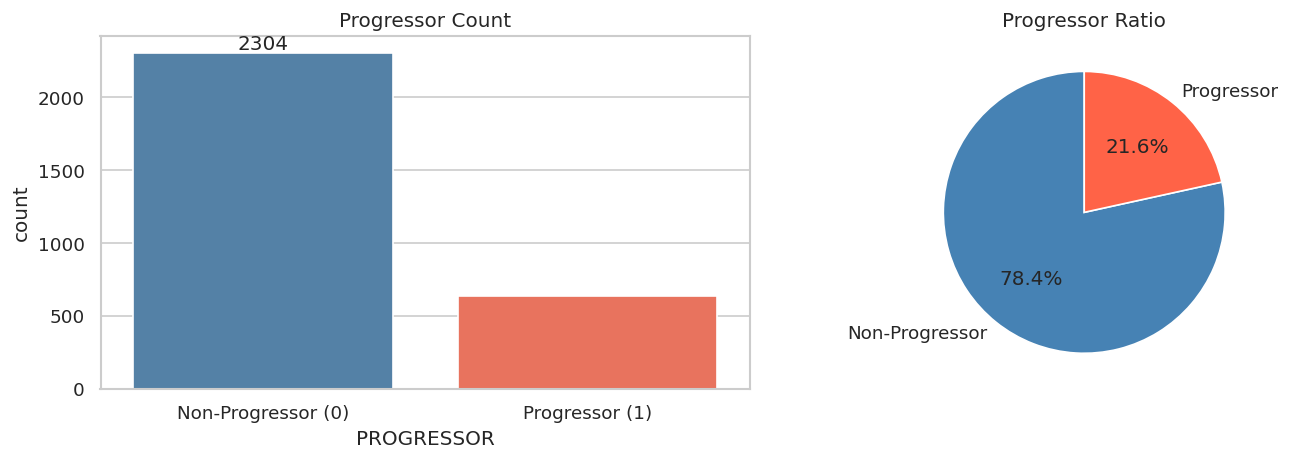

In [6]:
print('=== Target Distribution (Baseline) ===')
print(df_base['PROGRESSOR'].value_counts())
print(f"\nProgression rate: {df_base['PROGRESSOR'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# count plot
sns.countplot(data=df_base, x='PROGRESSOR', ax=axes[0], hue='PROGRESSOR', palette=['steelblue', 'tomato'], legend=False)
axes[0].set_title('Progressor Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Progressor (0)', 'Progressor (1)'])
axes[0].bar_label(axes[0].containers[0])

# pie chart
axes[1].pie(
    df_base['PROGRESSOR'].value_counts(),
    labels=['Non-Progressor', 'Progressor'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Progressor Ratio')

plt.tight_layout()
plt.show()

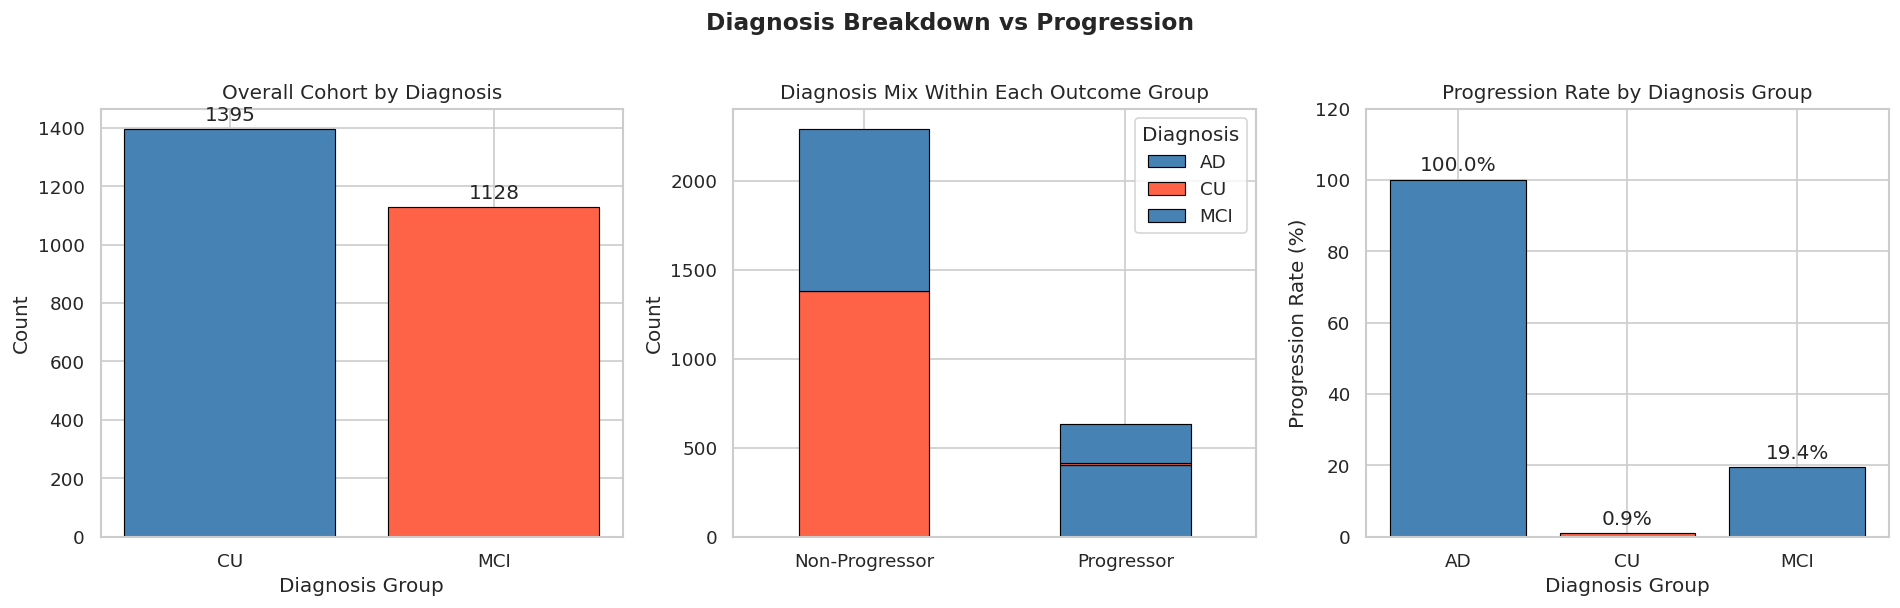

=== DIAGNOSIS BREAKDOWN ===

Overall cohort:
DIAGNOSIS_LABEL
CU     1395
MCI    1128
AD      402

Progression counts by diagnosis:
PROGRESSOR          0    1
DIAGNOSIS_LABEL           
AD                  0  402
CU               1383   12
MCI               909  219

Progression RATE by diagnosis:
  AD: 100.0%  (402 / 402 patients)
  CU: 0.9%  (12 / 1395 patients)
  MCI: 19.4%  (219 / 1128 patients)


In [7]:
# ── Step 3: Diagnosis Breakdown ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Diagnosis Breakdown vs Progression', fontsize=14, fontweight='bold', y=1.01)

# ── 3a: Overall CU vs MCI count ──────────────────────────────────────────────
diag_counts = df_base['DIAGNOSIS'].map({1: 'CU', 2: 'MCI'}).value_counts()
bars = axes[0].bar(diag_counts.index, diag_counts.values,
                   color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.7)
axes[0].bar_label(bars, fmt='%d', padding=3)
axes[0].set_title('Overall Cohort by Diagnosis')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Diagnosis Group')

# ── 3b: Stacked bar — CU/MCI within Progressors vs Non-Progressors ───────────
df_temp = df_base.copy()
#CHANGE FOR AD
#df_temp['DIAGNOSIS_LABEL'] = df_temp['DIAGNOSIS'].map({1: 'CU', 2: 'MCI'})
df_temp['DIAGNOSIS_LABEL'] = df_temp['DIAGNOSIS'].map({1: 'CU', 2: 'MCI', 3: 'AD'})
df_temp['PROGRESSOR_LABEL'] = df_temp['PROGRESSOR'].map({0: 'Non-Progressor', 1: 'Progressor'})

stacked = df_temp.groupby(['PROGRESSOR_LABEL', 'DIAGNOSIS_LABEL']).size().unstack(fill_value=0)
stacked.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.7
)
axes[1].set_title('Diagnosis Mix Within Each Outcome Group')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Diagnosis')

# ── 3c: Progression rate per diagnosis group ──────────────────────────────────
prog_rate = df_temp.groupby('DIAGNOSIS_LABEL')['PROGRESSOR'].mean() * 100
bars3 = axes[2].bar(prog_rate.index, prog_rate.values,
                    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.7)
axes[2].bar_label(bars3, fmt='%.1f%%', padding=3)
axes[2].set_title('Progression Rate by Diagnosis Group')
axes[2].set_ylabel('Progression Rate (%)')
axes[2].set_xlabel('Diagnosis Group')
axes[2].set_ylim(0, prog_rate.max() * 1.2)

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print("=== DIAGNOSIS BREAKDOWN ===")
print(f"\nOverall cohort:")
print(df_temp['DIAGNOSIS_LABEL'].value_counts().to_string())

print(f"\nProgression counts by diagnosis:")
print(df_temp.groupby('DIAGNOSIS_LABEL')['PROGRESSOR'].value_counts().unstack(fill_value=0).to_string())

print(f"\nProgression RATE by diagnosis:")
for diag, rate in prog_rate.items():
    n_prog = df_temp[(df_temp['DIAGNOSIS_LABEL']==diag) & (df_temp['PROGRESSOR']==1)].shape[0]
    n_total = df_temp[df_temp['DIAGNOSIS_LABEL']==diag].shape[0]
    print(f"  {diag}: {rate:.1f}%  ({n_prog} / {n_total} patients)")

# clean up temp columns
df_base = df_base.drop(columns=['DIAGNOSIS_LABEL', 'PROGRESSOR_LABEL'], errors='ignore')

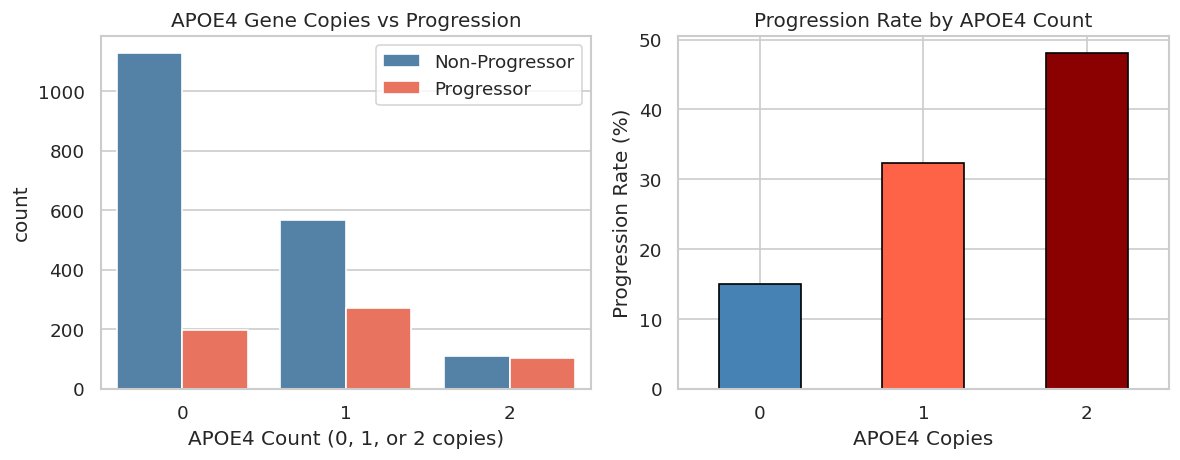

Progression Rate by APOE4 Count:
APOE4_COUNT
0    14.932127
1    32.254197
2    48.095238
Name: PROGRESSOR, dtype: float64


In [8]:
df_base['APOE4_COUNT'] = df_base['APOE4_COUNT'].round().astype('Int64')

df_base['APOE4_COUNT'] = df_base['APOE4_COUNT'].clip(0, 2)

plt.figure(figsize=(10, 4))

# APOE4 count distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df_base, x='APOE4_COUNT', hue='PROGRESSOR', palette=['steelblue', 'tomato'])
plt.title('APOE4 Gene Copies vs Progression')
plt.xlabel('APOE4 Count (0, 1, or 2 copies)')
plt.legend(['Non-Progressor', 'Progressor'])

# Progression rate by APOE4
plt.subplot(1, 2, 2)
apoe4_rate = df_base.groupby('APOE4_COUNT')['PROGRESSOR'].mean() * 100
apoe4_rate.plot(kind='bar', color=['steelblue', 'tomato', 'darkred'], edgecolor='black')
plt.title('Progression Rate by APOE4 Count')
plt.xlabel('APOE4 Copies')
plt.ylabel('Progression Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("Progression Rate by APOE4 Count:")
print(df_base.groupby('APOE4_COUNT')['PROGRESSOR'].mean() * 100)

In [9]:
# ── Step 4: Univariate Distributions (Raw Data) ──────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

demographic_features = [
    'PTGENDER',     # Gender
    'PTEDUCAT',     # Years of Education
    'PTMARRY',      # Marital Status
    'APOE4_COUNT',  # Derived from GENOTYPE
    'AGE'
]

cognitive_features = [
    # Logical Memory
    'LIMMTOTAL',    # Logical Memory Immediate
    'LDELTOTAL',    # Logical Memory Delayed
    # RAVLT
    'AVTOT1', 'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5', 'AVTOT6',
    'AVDEL30MIN',   # RAVLT 30-min Delayed Recall
    'AVDELTOT',     # RAVLT Recognition Score
    # Language
    'CATANIMSC',    # Category Fluency: Animals
    # Global cognition
    'MMSCORE',      # MMSE Total Score
    'CDRSB',        # CDR Sum of Boxes
    # Functional
    'FAQTOTAL',     # FAQ Total
    # ADAS
    'TOTSCORE',     # ADAS-Cog 70-pt
    'TOTAL13',      # ADAS-Cog 85-pt
]

imaging_features = [
    'BRAINVOL',     # Whole Brain Volume
    'VENTVOL',      # Ventricular Volume
    'TOTAL_HIPPO',  # Total Hippocampal Volume
]

feature_labels = {
    # Demographics
    'PTGENDER':     'Gender',
    'PTEDUCAT':     'Years of Education',
    'PTDOB':        'Date of Birth',
    'PTMARRY':      'Marital Status',
    'APOE4_COUNT':  'APOE4 Allele Count',
    # Cognitive
    'LIMMTOTAL':    'Logical Memory Immediate',
    'LDELTOTAL':    'Logical Memory Delayed',
    'AVTOT1':       'RAVLT Trial 1',
    'AVTOT2':       'RAVLT Trial 2',
    'AVTOT3':       'RAVLT Trial 3',
    'AVTOT4':       'RAVLT Trial 4',
    'AVTOT5':       'RAVLT Trial 5',
    'AVTOT6':       'RAVLT Trial 6',
    'AVDEL30MIN':   'RAVLT 30-min Delayed Recall',
    'AVDELTOT':     'RAVLT Recognition Score',
    'CATANIMSC':    'Category Fluency: Animals',
    'MMSCORE':      'MMSE Total Score',
    'CDRSB':        'CDR Sum of Boxes',
    'FAQTOTAL':     'FAQ Total Score',
    'TOTSCORE':     'ADAS-Cog (70-pt)',
    'TOTAL13':      'ADAS-Cog (85-pt)',
    # Imaging
    'BRAINVOL':     'Whole Brain Volume',
    'VENTVOL':      'Ventricular Volume',
    'TOTAL_HIPPO':  'Total Hippocampal Volume',
}


def plot_univariate_group(features, group_title, df, categorical=None):
    n = len(features)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    fig.suptitle(f'Univariate Distributions: {group_title}', fontsize=14, fontweight='bold', y=1.01)
    axes = axes.flatten()

    for i, col in enumerate(features):
        ax = axes[i]
        data = df[col].dropna()
        label = feature_labels.get(col, col)
        n_valid = data.shape[0]
        pct_valid = n_valid / len(df) * 100

        if categorical and col in categorical:
            # Bar chart for categoricals
            counts = data.value_counts().sort_index()
            ax.bar(counts.index.astype(str), counts.values,
                   color='steelblue', edgecolor='black', linewidth=0.6)
            ax.set_title(f'{label}\n({pct_valid:.0f}% non-null)', fontsize=10)
            ax.set_xlabel('')
        else:
            # Histogram + KDE for continuous
            ax.hist(data, bins=30, color='steelblue', edgecolor='white',
                    linewidth=0.4, density=True, alpha=0.7)
            data.plot(kind='kde', ax=ax, color='tomato', linewidth=1.5)

            skew = data.skew()
            ax.set_title(
                f'{label}\n({pct_valid:.0f}% non-null  |  skew={skew:.2f})',
                fontsize=9
            )
            ax.set_xlabel('')

        ax.set_ylabel('')
        ax.tick_params(labelsize=8)

    # hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

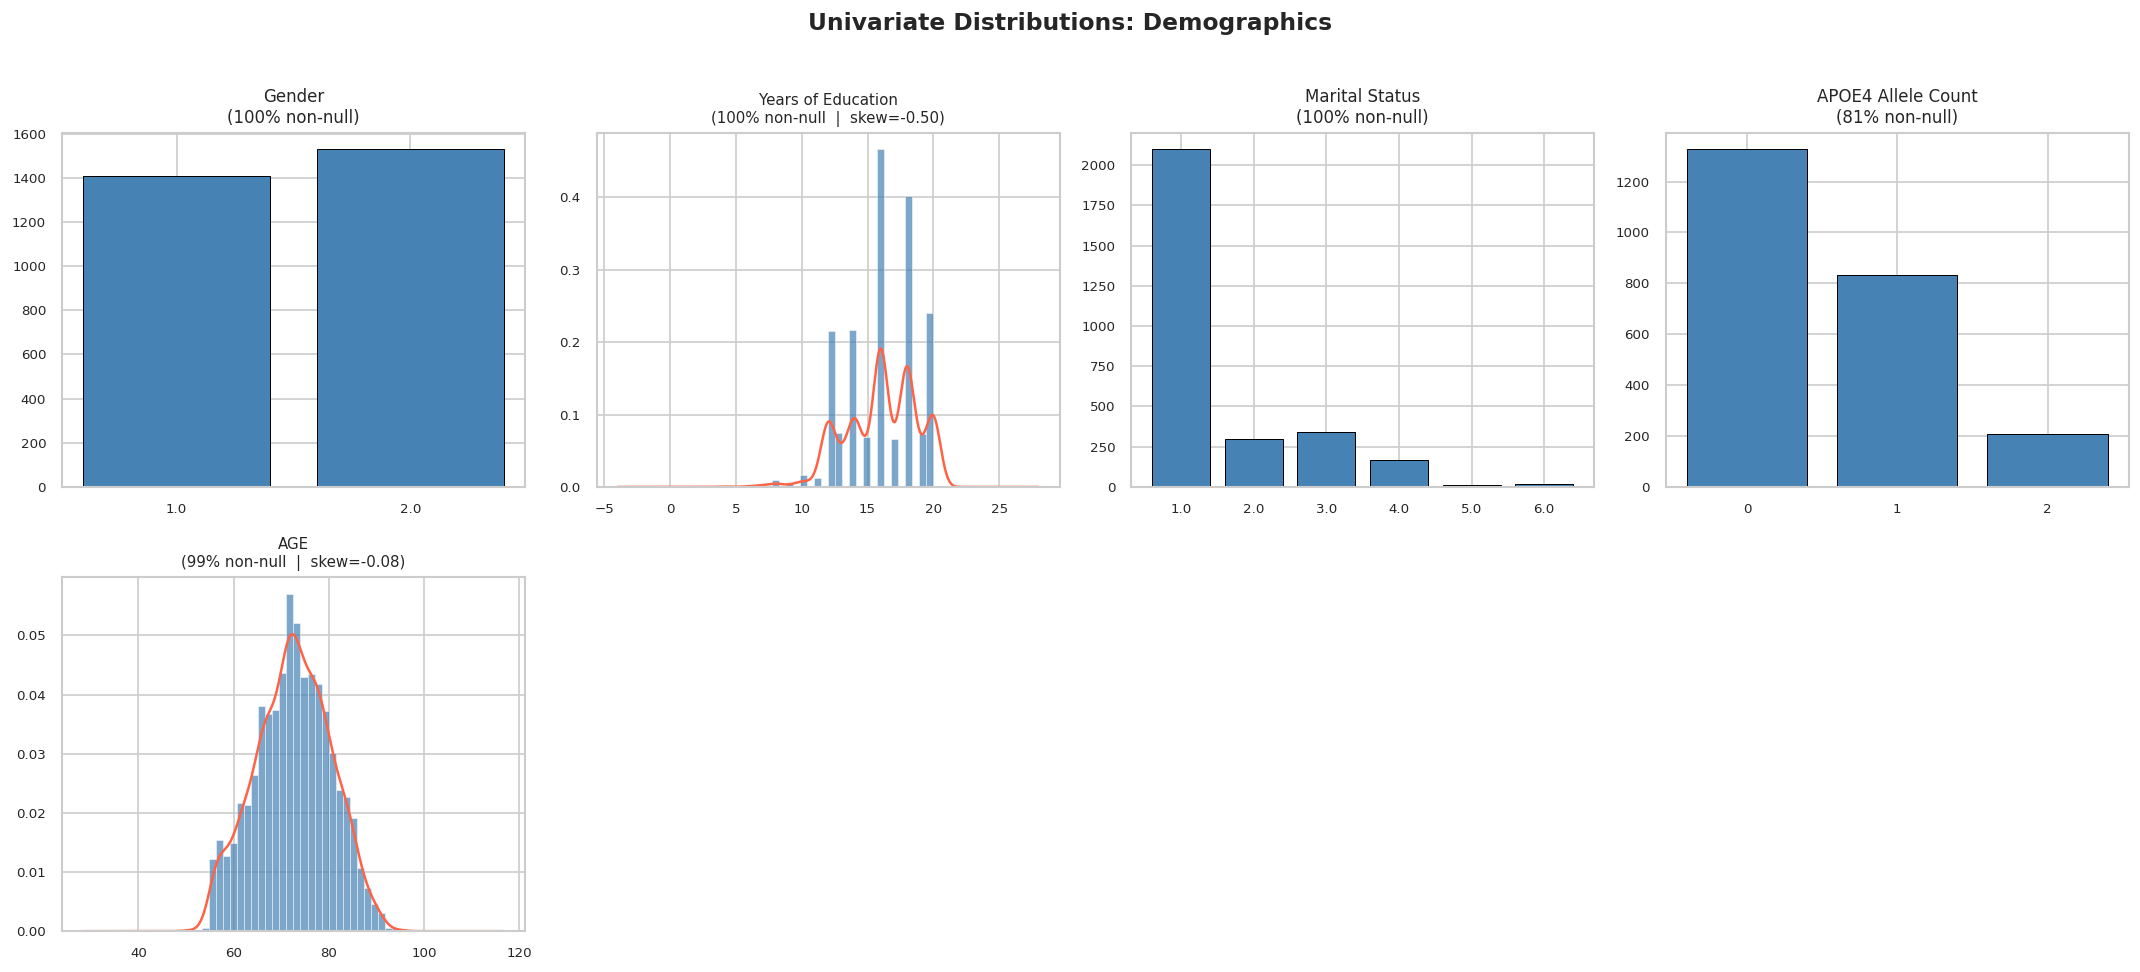

In [10]:
plot_univariate_group(
    demographic_features, 'Demographics',
    df_base, categorical=['PTGENDER', 'PTMARRY','APOE4_COUNT']
)

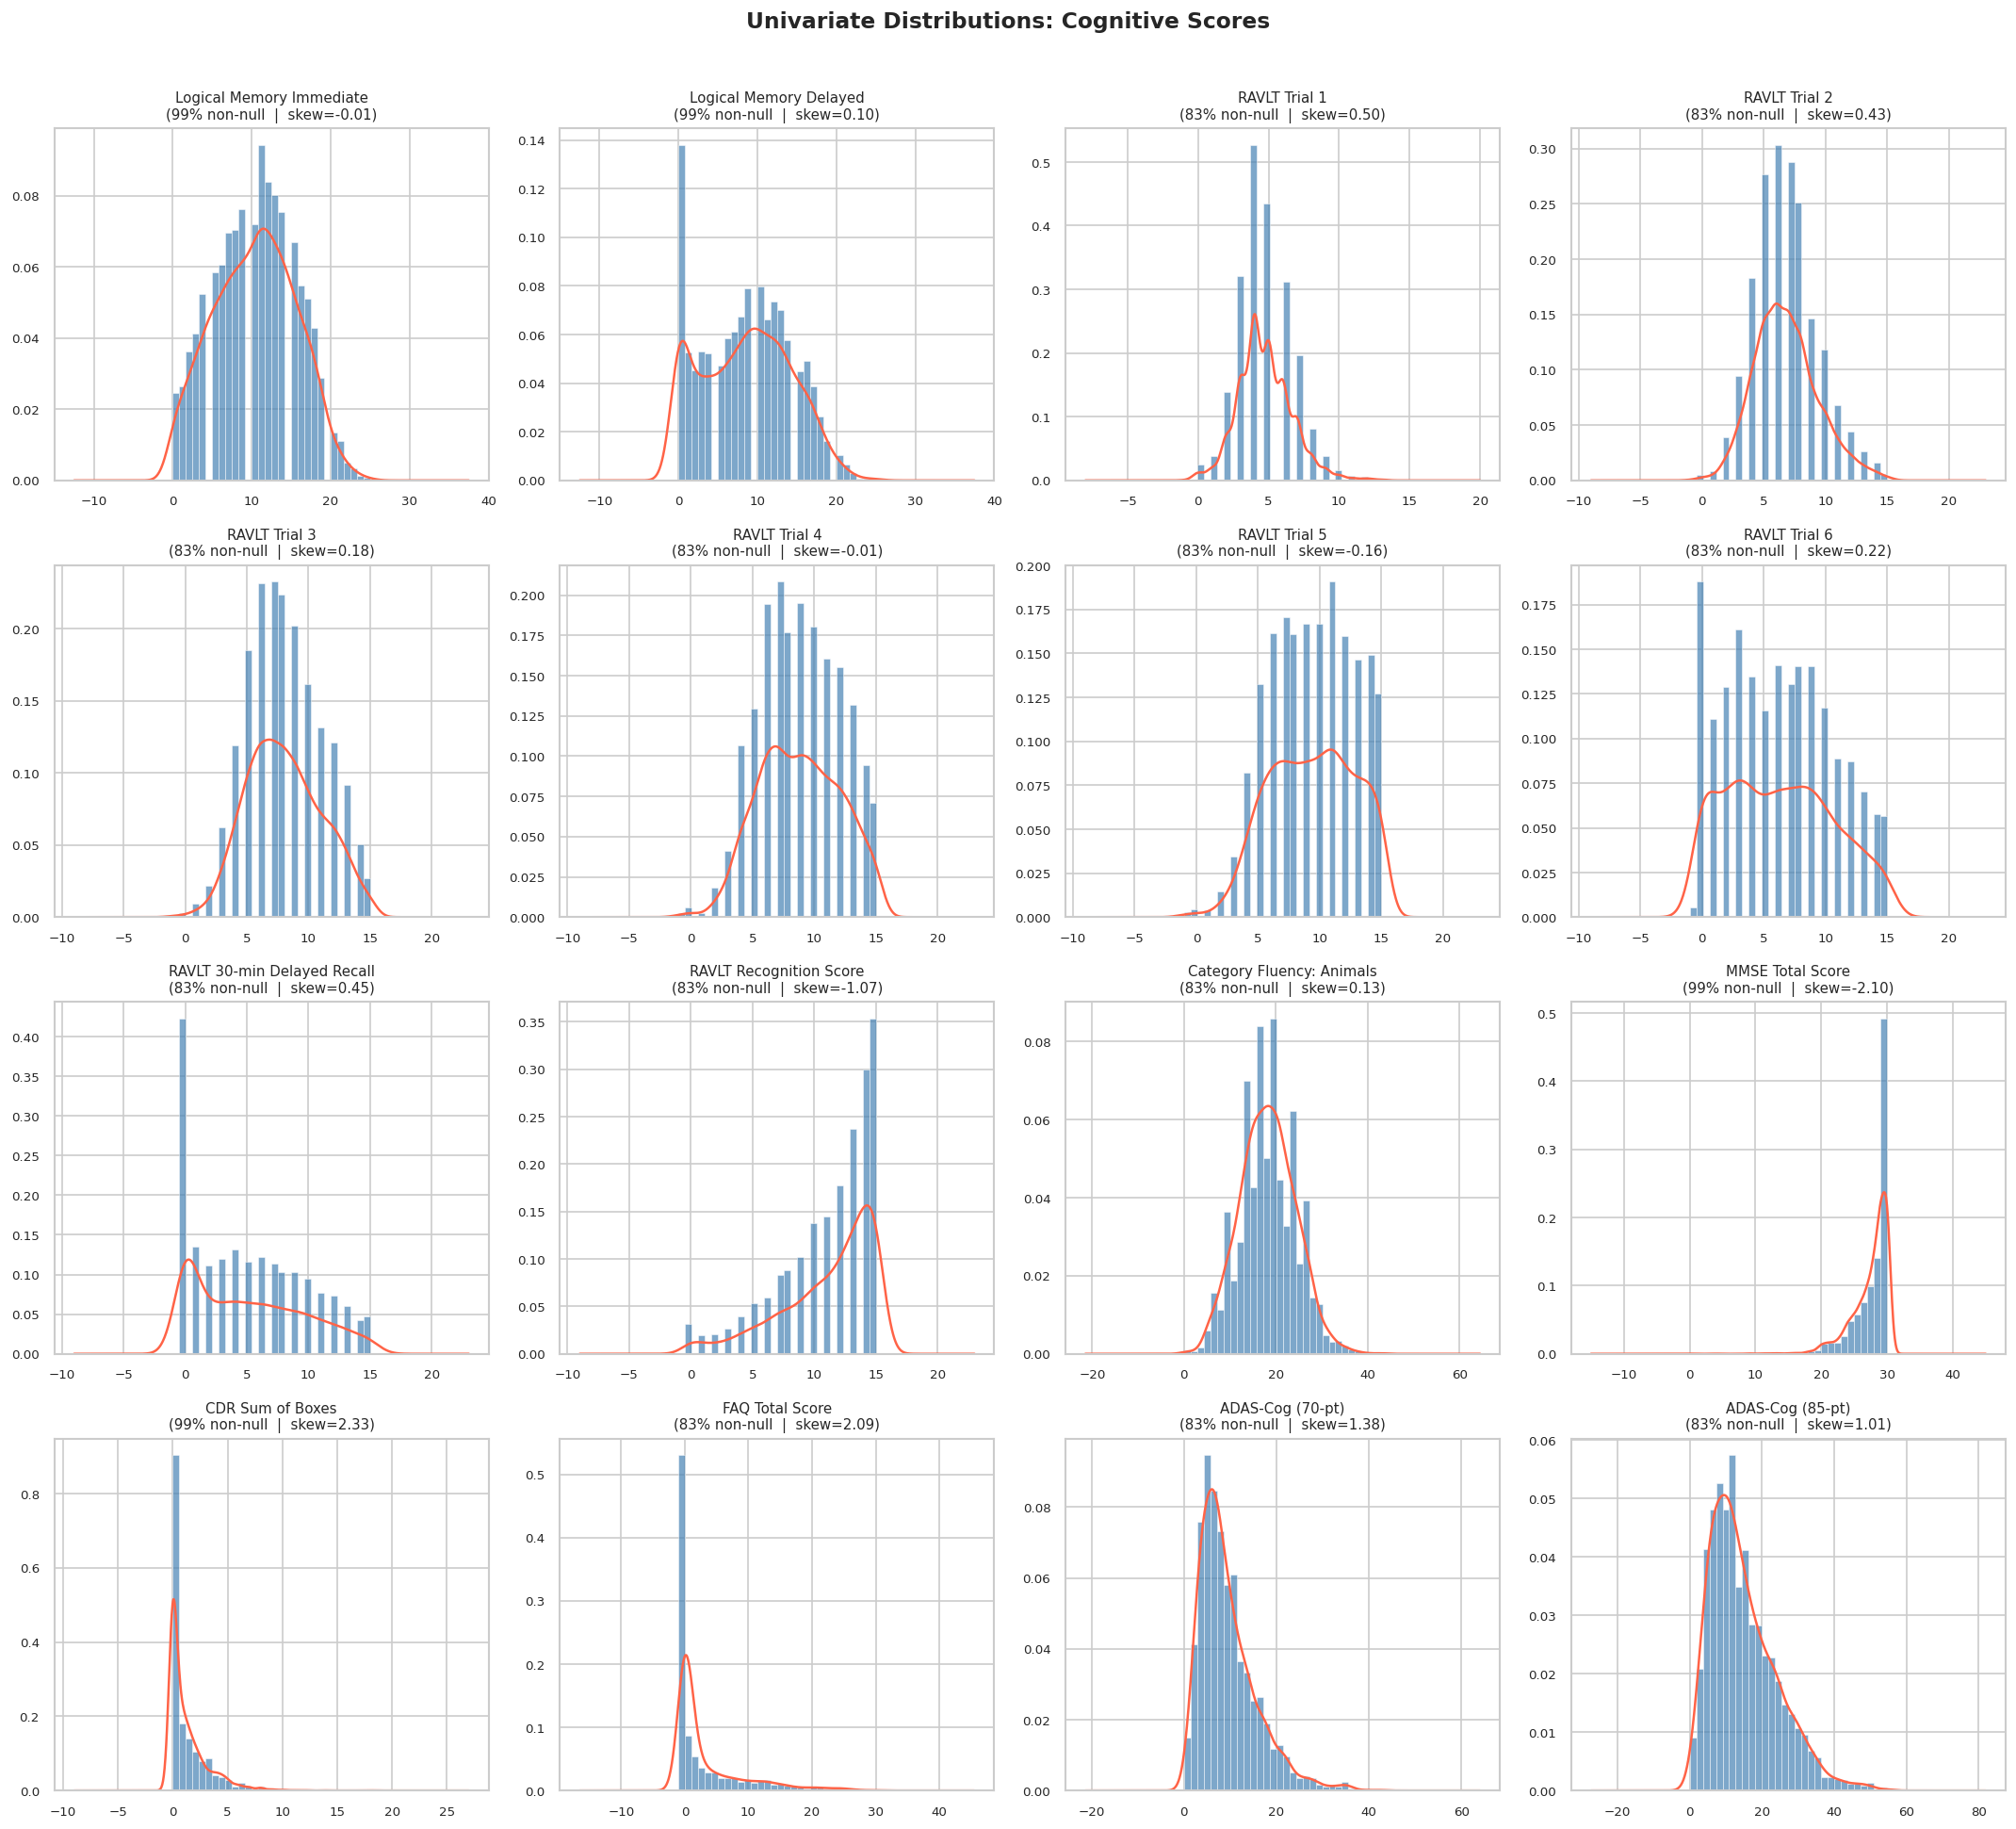

In [11]:
plot_univariate_group(cognitive_features, 'Cognitive Scores', df_base)

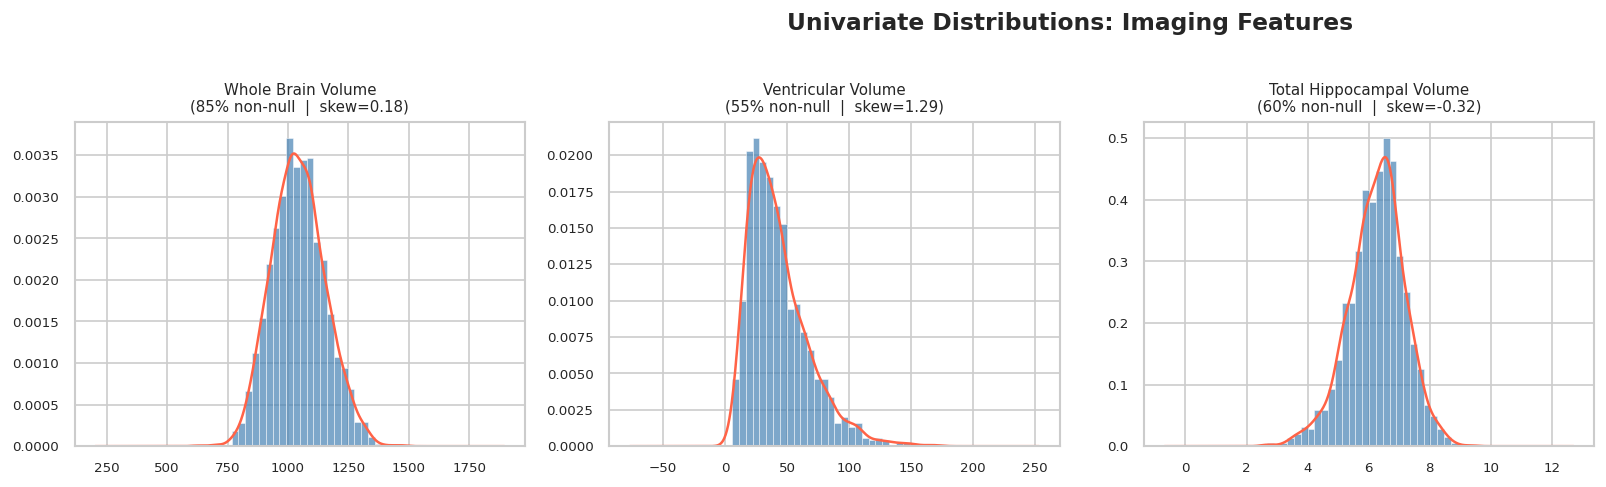

In [12]:
plot_univariate_group(imaging_features, 'Imaging Features', df_base)

In [13]:
print("=== SKEWNESS SUMMARY ===")
all_continuous = [f for f in cognitive_features + imaging_features + ['AGE', 'PTEDUCAT']]
skew_df = pd.DataFrame({
    'Feature': all_continuous,
    'Skewness': [df_base[c].dropna().skew() for c in all_continuous],
    'Non-null %': [df_base[c].notna().mean()*100 for c in all_continuous]
}).sort_values('Skewness', key=abs, ascending=False)
skew_df['Flag'] = skew_df['Skewness'].apply(
    lambda s: '⚠️ High skew' if abs(s) > 1 else ('Moderate' if abs(s) > 0.5 else 'Normal')
)
print(skew_df.to_string(index=False))

=== SKEWNESS SUMMARY ===
    Feature  Skewness  Non-null %         Flag
      CDRSB  2.328664   98.808308 ⚠️ High skew
    MMSCORE -2.095283   99.216888 ⚠️ High skew
   FAQTOTAL  2.093927   82.839632 ⚠️ High skew
   TOTSCORE  1.381760   82.975826 ⚠️ High skew
    VENTVOL  1.288021   55.124276 ⚠️ High skew
   AVDELTOT -1.070419   83.248212 ⚠️ High skew
    TOTAL13  1.008328   82.635342 ⚠️ High skew
   PTEDUCAT -0.504333   99.829758     Moderate
     AVTOT1  0.499142   83.418454       Normal
 AVDEL30MIN  0.448133   83.350358       Normal
     AVTOT2  0.428568   83.418454       Normal
TOTAL_HIPPO -0.324915   59.618658       Normal
     AVTOT6  0.217261   83.282261       Normal
   BRAINVOL  0.176533   85.495403       Normal
     AVTOT3  0.175409   83.418454       Normal
     AVTOT5 -0.155319   83.384406       Normal
  CATANIMSC  0.127233   83.486551       Normal
  LDELTOTAL  0.097817   99.250936       Normal
        AGE -0.078869   98.842356       Normal
     AVTOT4 -0.012640   83.384406  

In [14]:
def cohens_d(g0, g1):
    """Cohen's d effect size for two independent groups"""
    n0, n1 = len(g0), len(g1)
    pooled_std = np.sqrt(((n0 - 1) * g0.std()**2 + (n1 - 1) * g1.std()**2) / (n0 + n1 - 2))
    return (g1.mean() - g0.mean()) / pooled_std

In [15]:
all_features_full = [
    # Demographics
    'PTGENDER',     # Gender
    'PTEDUCAT',     # Years of Education
    'PTMARRY',      # Marital Status
    'APOE4_COUNT',  # Derived from GENOTYPE
    'AGE',
    # Cognitive
    'LIMMTOTAL',    # Logical Memory Immediate
    'LDELTOTAL',    # Logical Memory Delayed
    'AVTOT1', 'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5', 'AVTOT6',
    'AVDEL30MIN',   # RAVLT 30-min Delayed Recall
    'AVDELTOT',     # RAVLT Recognition Score
    'CATANIMSC',    # Category Fluency: Animals
    'MMSCORE',      # MMSE Total Score
    'CDRSB',        # CDR Sum of Boxes
    'FAQTOTAL',     # FAQ Total
    'TOTSCORE',     # ADAS-Cog 70-pt
    'TOTAL13',      # ADAS-Cog 85-pt
    # Imaging
    'BRAINVOL',     # Whole Brain Volume
    'VENTVOL',      # Ventricular Volume
    'TOTAL_HIPPO'  # Total Hippocampal Volume
]

full_results = []
for col in all_features_full:
    g0 = df_base[df_base['PROGRESSOR'] == 0][col].dropna()
    g1 = df_base[df_base['PROGRESSOR'] == 1][col].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    d       = cohens_d(g0, g1)
    sig     = '✅' if p < 0.05 else '❌'
    effect  = 'Large' if abs(d) >= 0.8 else ('Medium' if abs(d) >= 0.5 else 'Small')
    full_results.append({
        'Feature': col, 'p-value': round(p, 4),
        "Cohen's d": d, 'Effect Size': effect, 'Sig': sig,
        'Note': 'full cohort'
    })


summary_df = pd.DataFrame(full_results).sort_values("Cohen's d", key=abs, ascending=False)
print(summary_df[['Feature', 'p-value', "Cohen's d", 'Effect Size', 'Sig', 'Note']].to_string(index=False))

large  = (summary_df['Effect Size'] == 'Large').sum()
medium = (summary_df['Effect Size'] == 'Medium').sum()
small  = (summary_df['Effect Size'] == 'Small').sum()
print(f"\nEffect size breakdown → Large: {large}  Medium: {medium}  Small: {small}")

    Feature  p-value  Cohen's d Effect Size Sig        Note
      CDRSB      0.0   2.196978       Large   ✅ full cohort
    TOTAL13      0.0   2.070652       Large   ✅ full cohort
   TOTSCORE      0.0   1.960357       Large   ✅ full cohort
   FAQTOTAL      0.0   1.923830       Large   ✅ full cohort
    MMSCORE      0.0  -1.879923       Large   ✅ full cohort
  LDELTOTAL      0.0  -1.745356       Large   ✅ full cohort
     AVTOT5      0.0  -1.600678       Large   ✅ full cohort
  LIMMTOTAL      0.0  -1.585377       Large   ✅ full cohort
     AVTOT4      0.0  -1.475683       Large   ✅ full cohort
     AVTOT6      0.0  -1.450010       Large   ✅ full cohort
     AVTOT3      0.0  -1.357915       Large   ✅ full cohort
 AVDEL30MIN      0.0  -1.314415       Large   ✅ full cohort
   AVDELTOT      0.0  -1.310933       Large   ✅ full cohort
TOTAL_HIPPO      0.0  -1.195193       Large   ✅ full cohort
     AVTOT2      0.0  -1.176141       Large   ✅ full cohort
  CATANIMSC      0.0  -1.131732       La

--- Progression Counts by Diagnosis Subgroup ---

CU Subgroup Progression:
PROGRESSOR
0    1383
1      12
Name: count, dtype: int64
Progression rate in CU: 0.9%

MCI Subgroup Progression:
PROGRESSOR
0    909
1    219
Name: count, dtype: int64
Progression rate in MCI: 19.4%


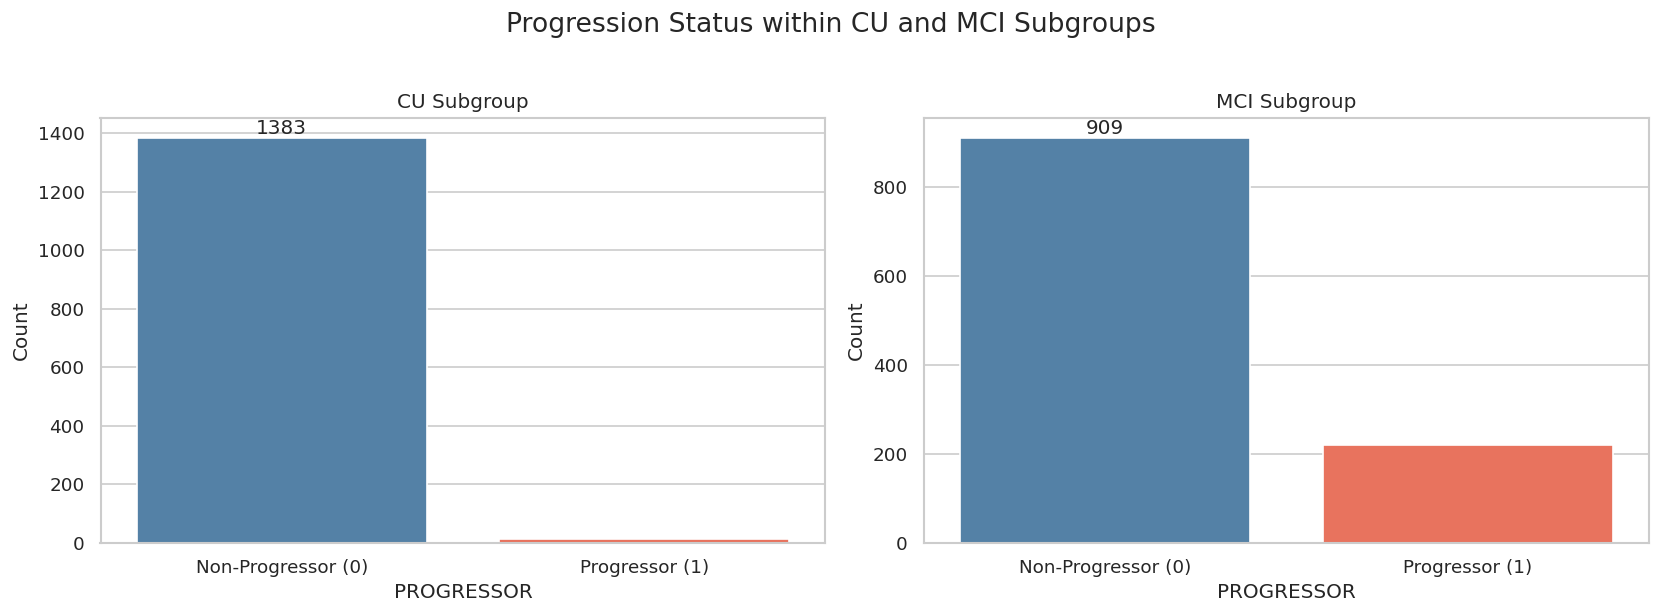


--- Feature Distributions by Diagnosis Subgroup ---


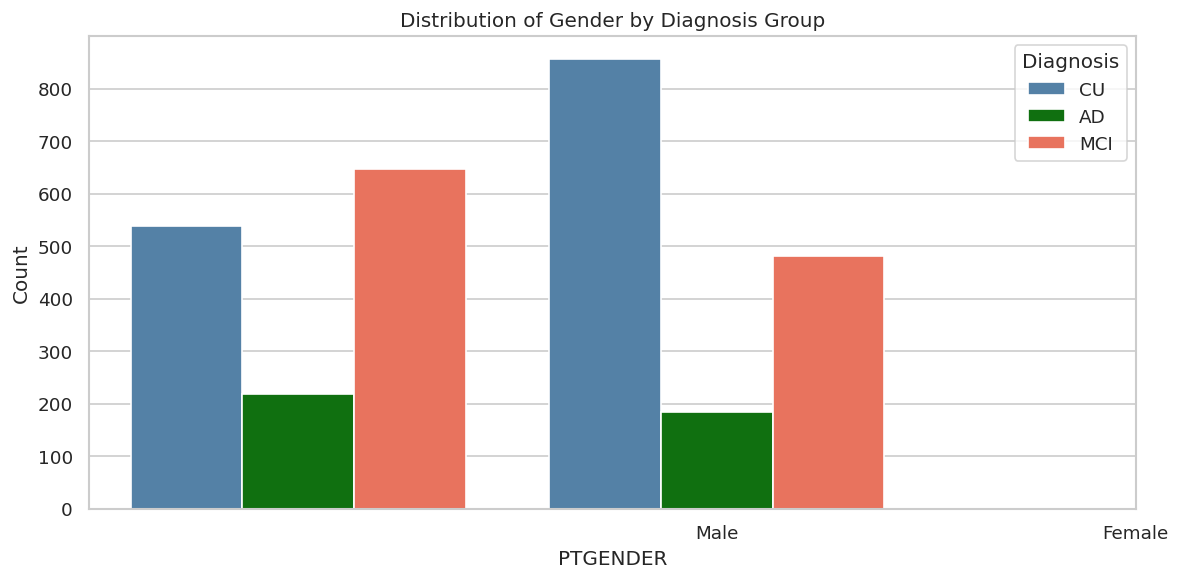

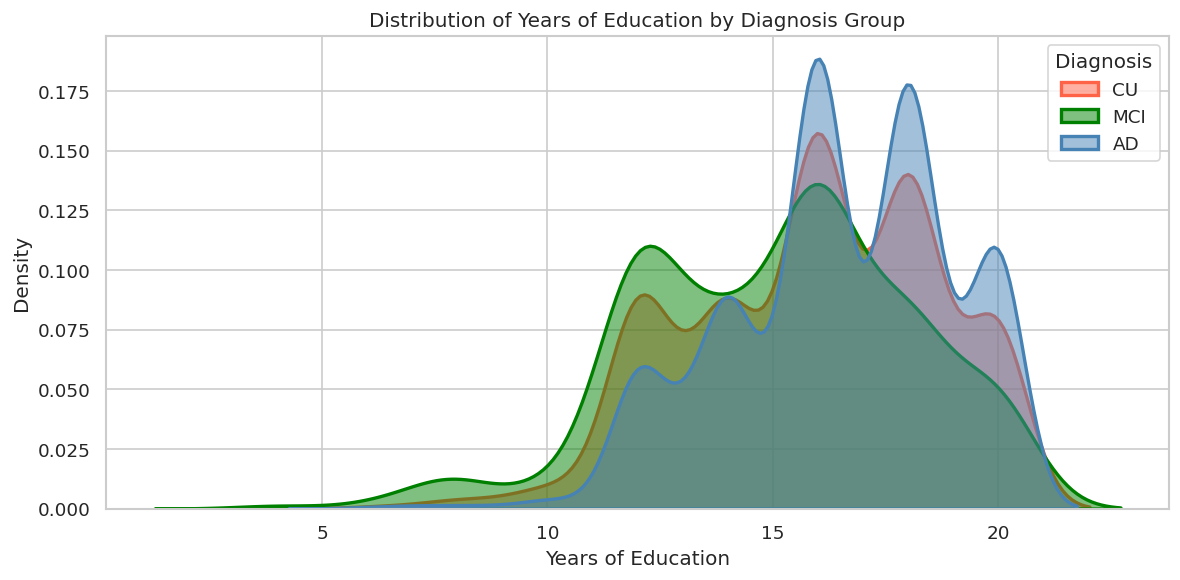

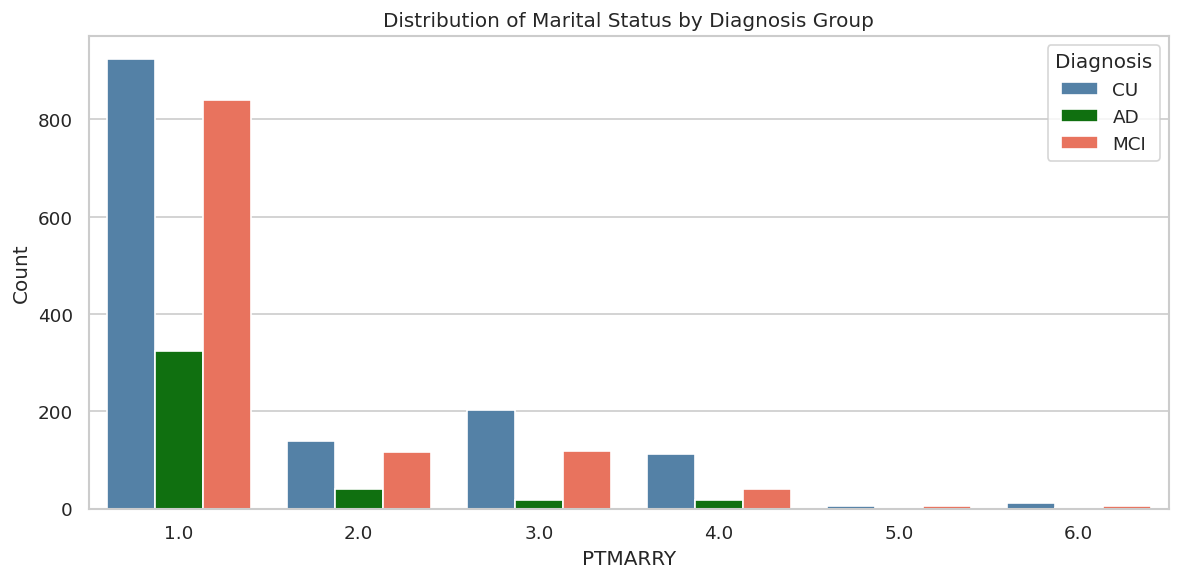

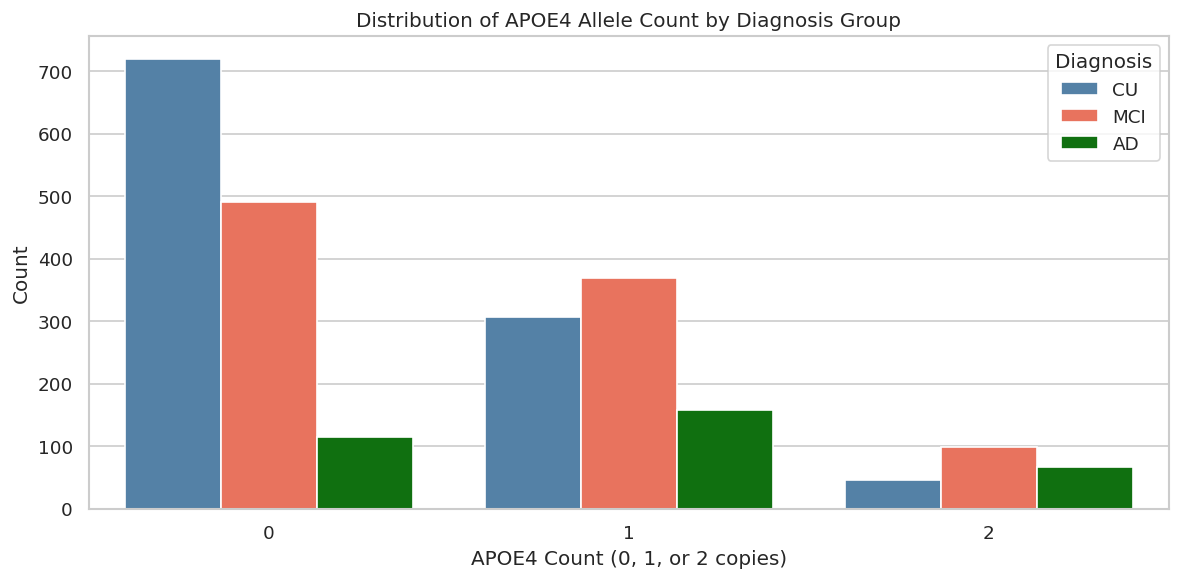

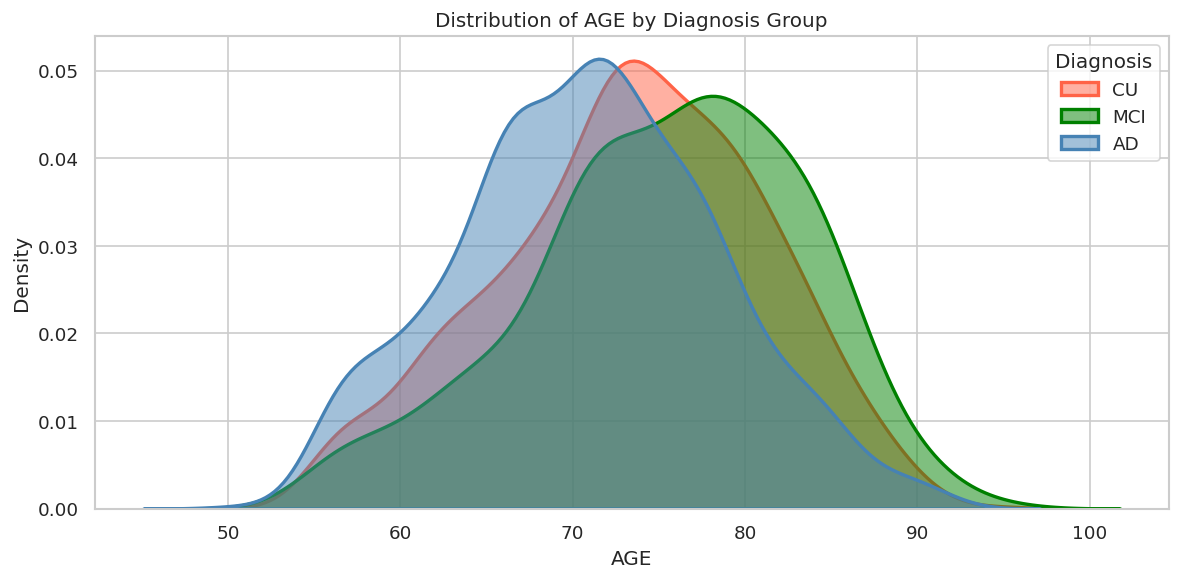

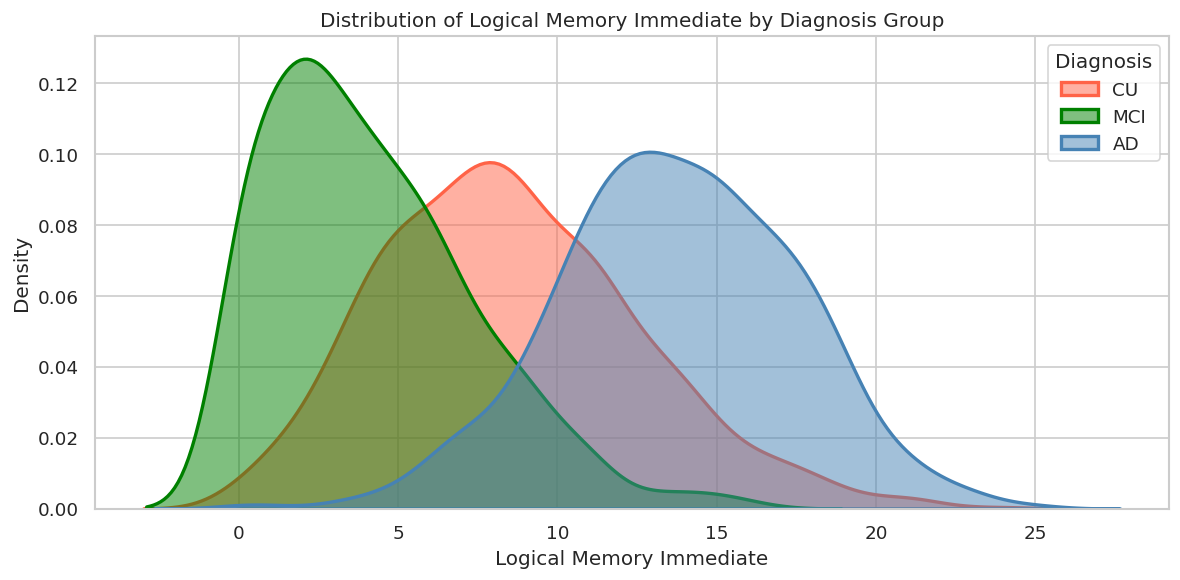

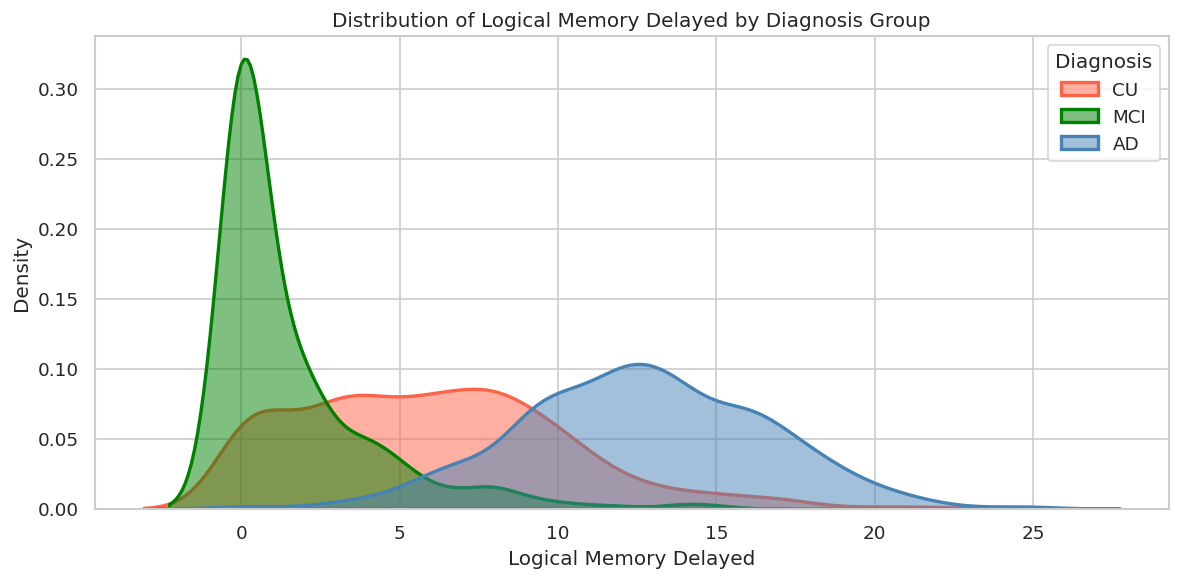

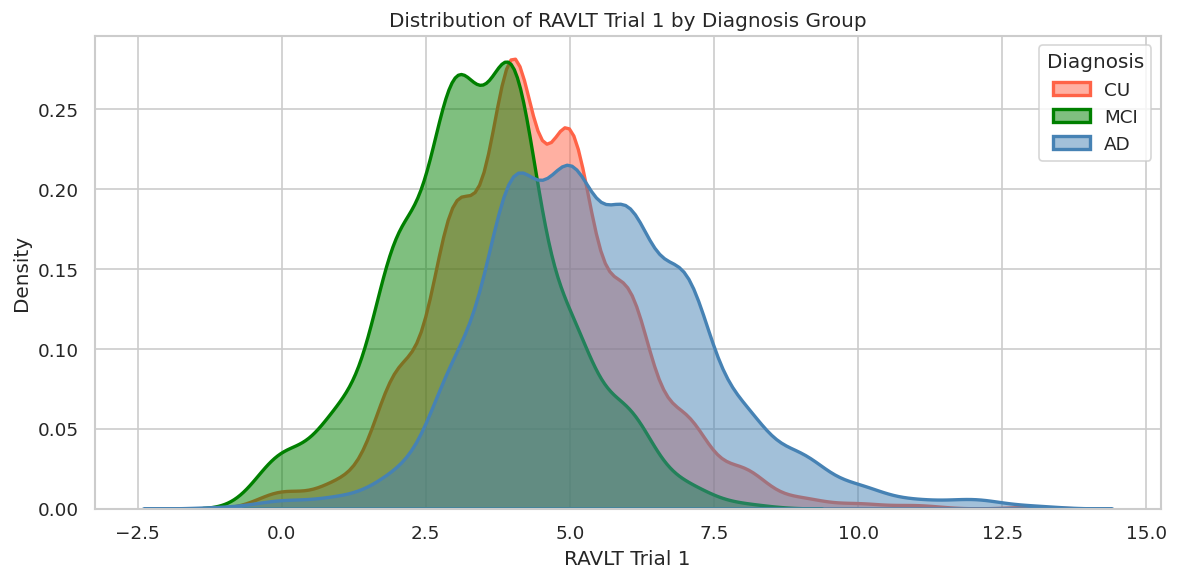

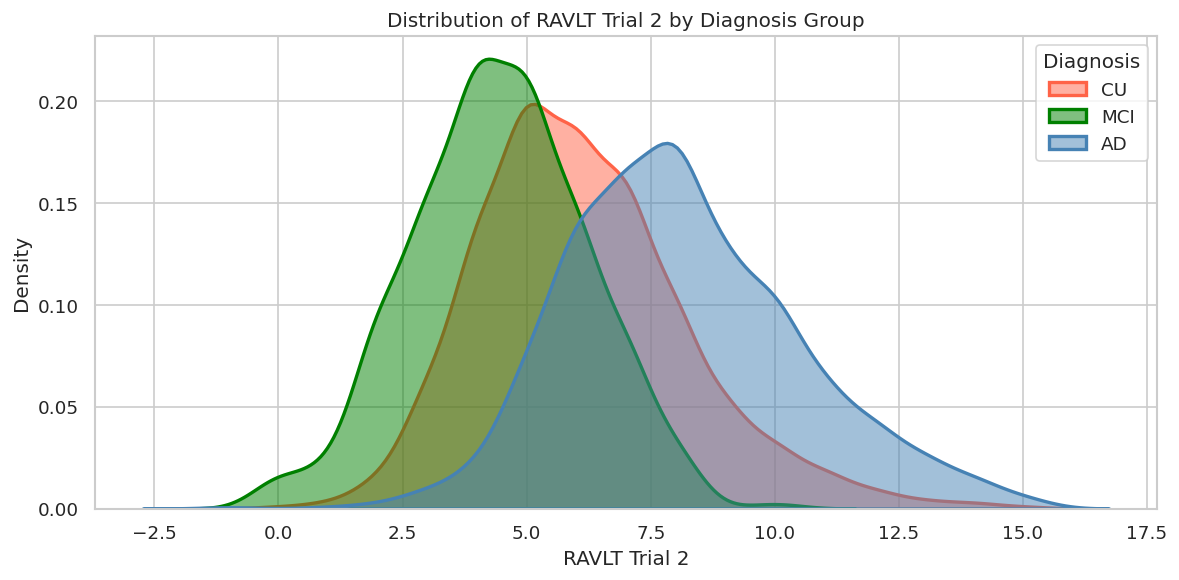

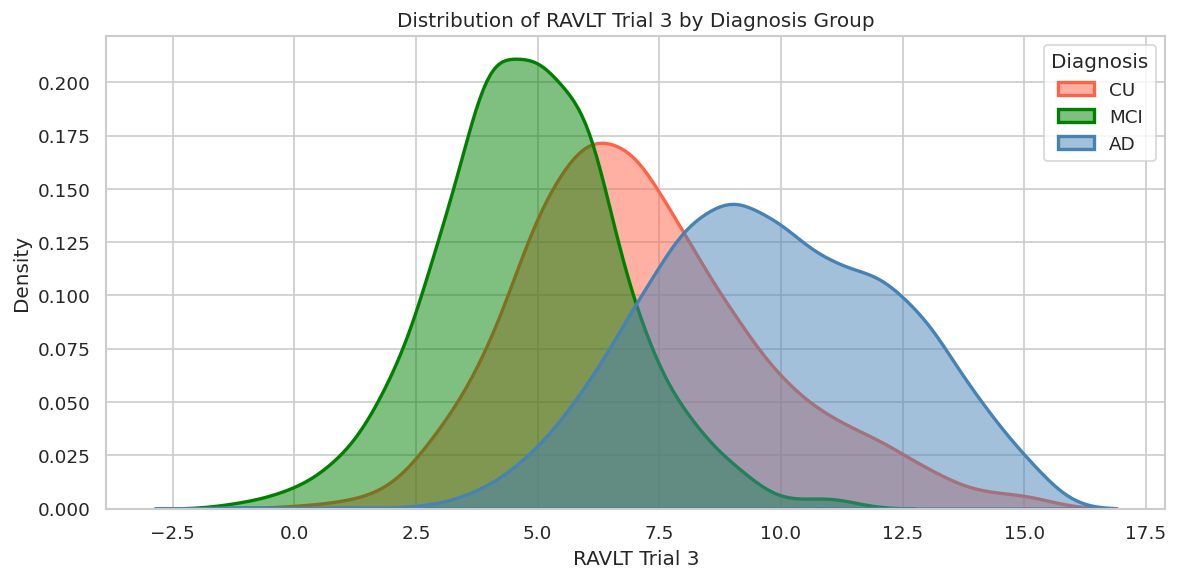

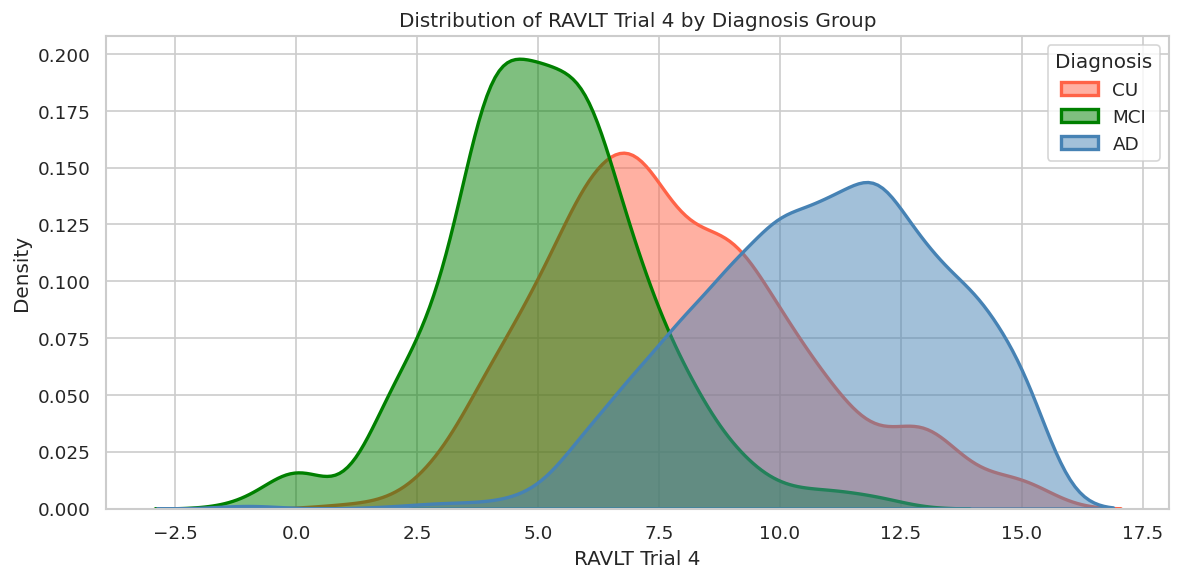

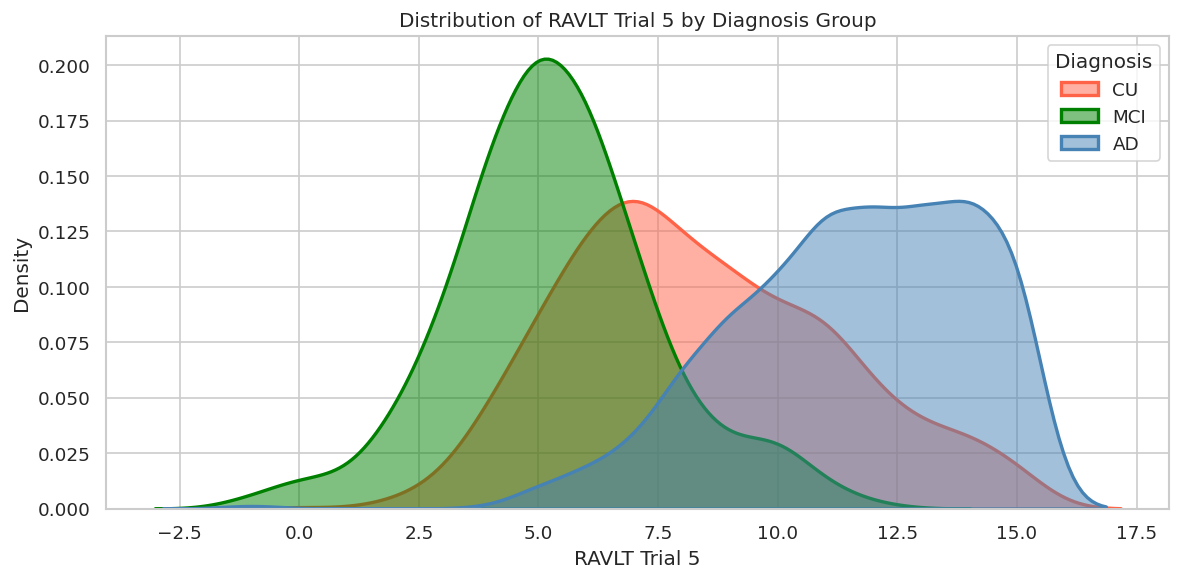

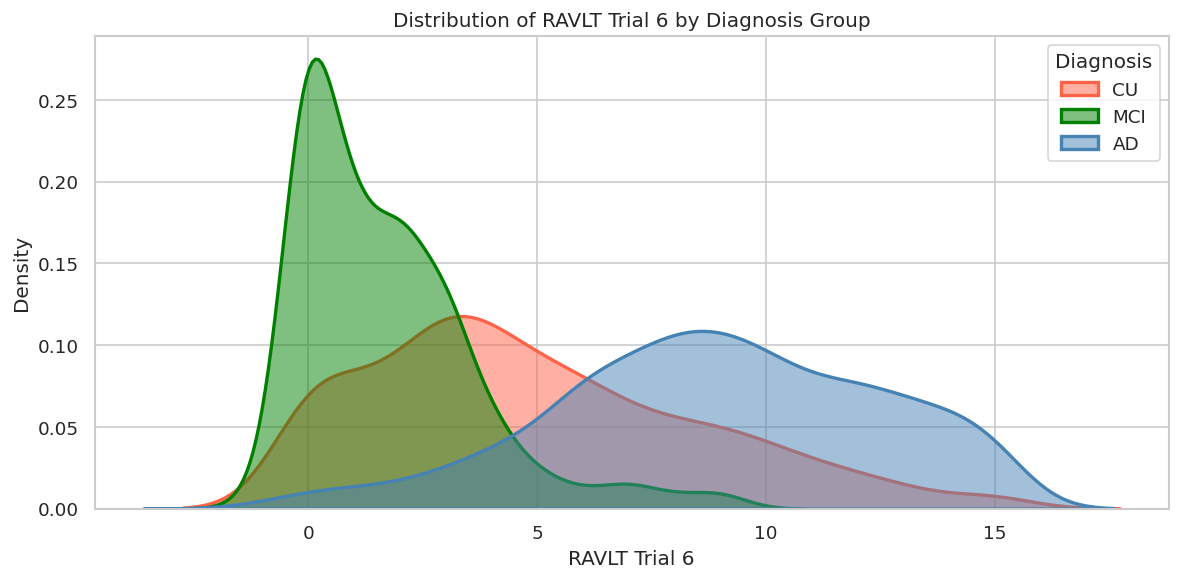

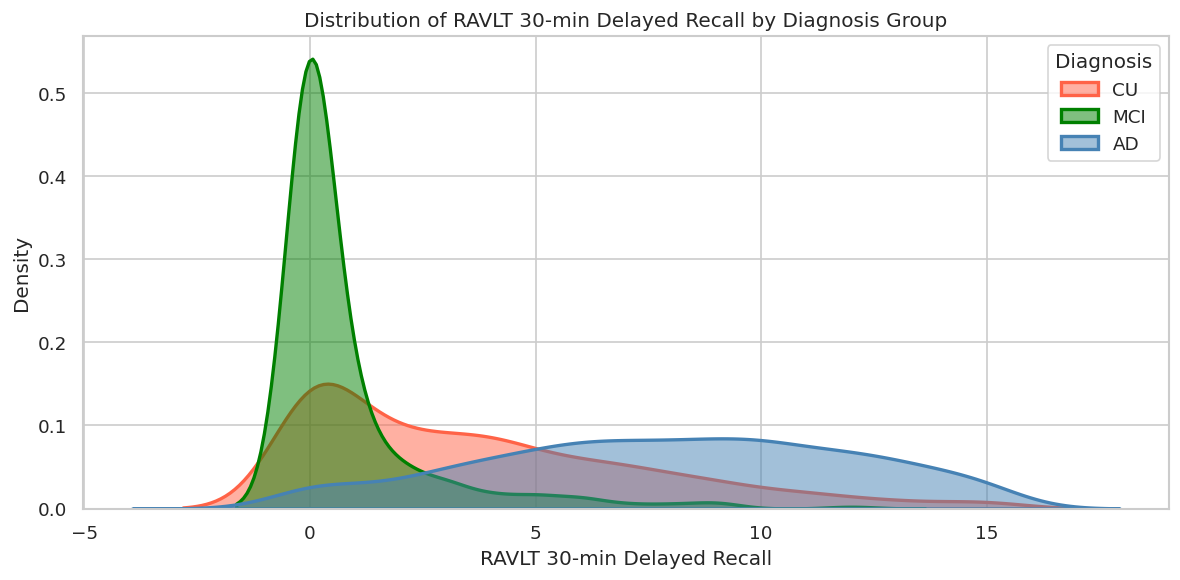

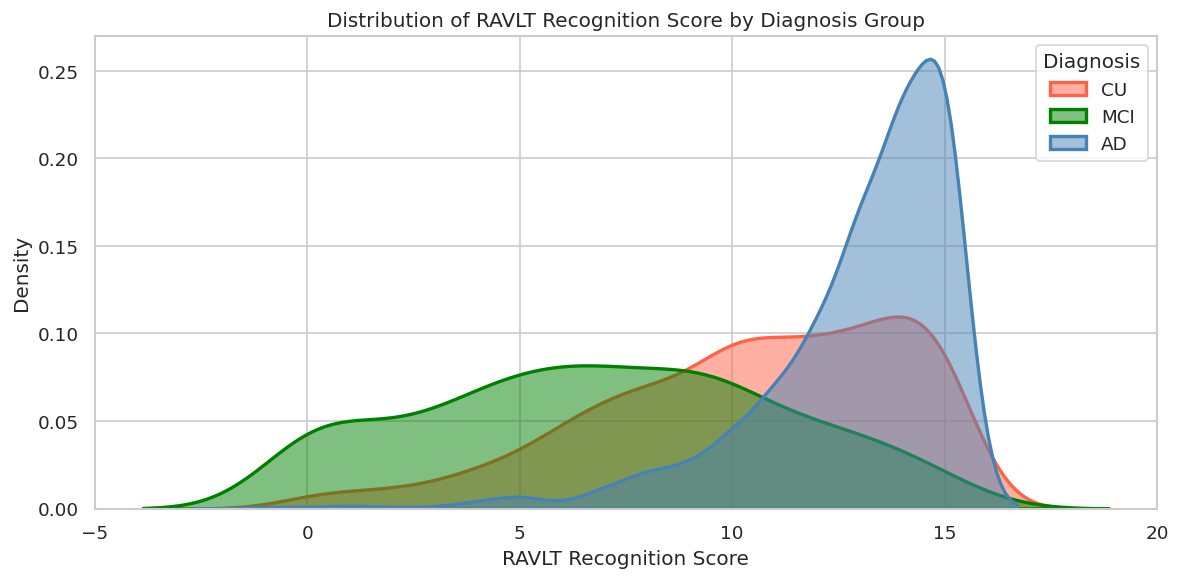

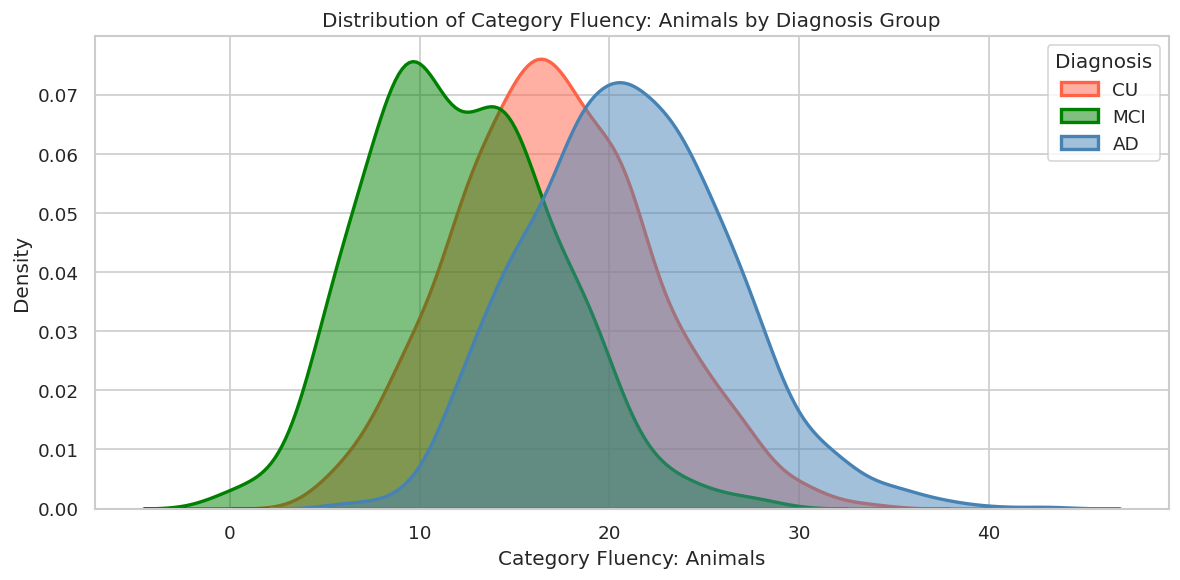

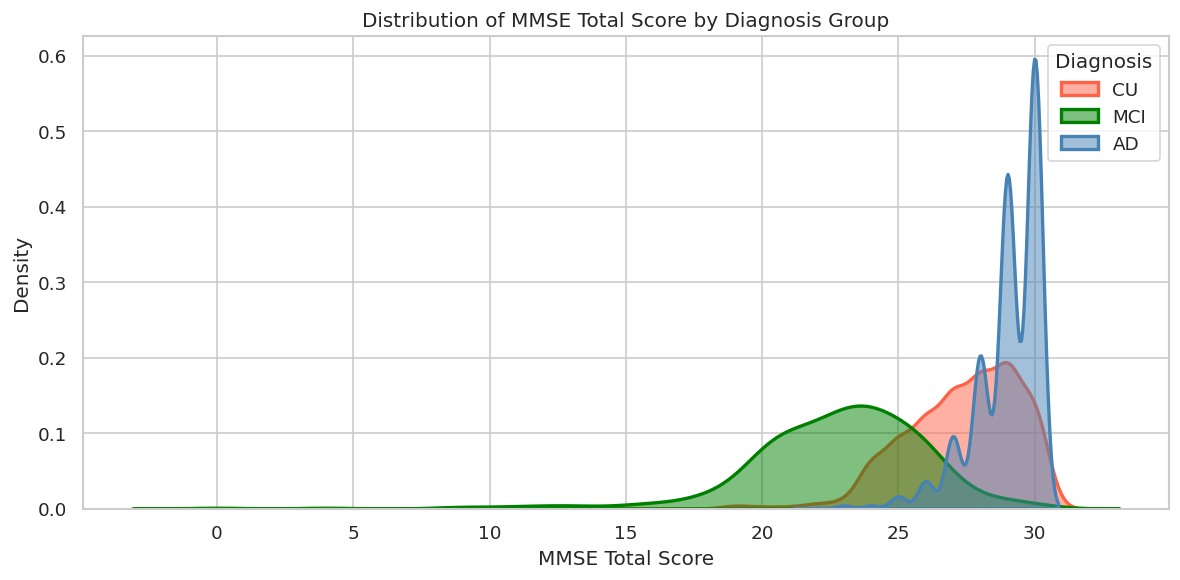

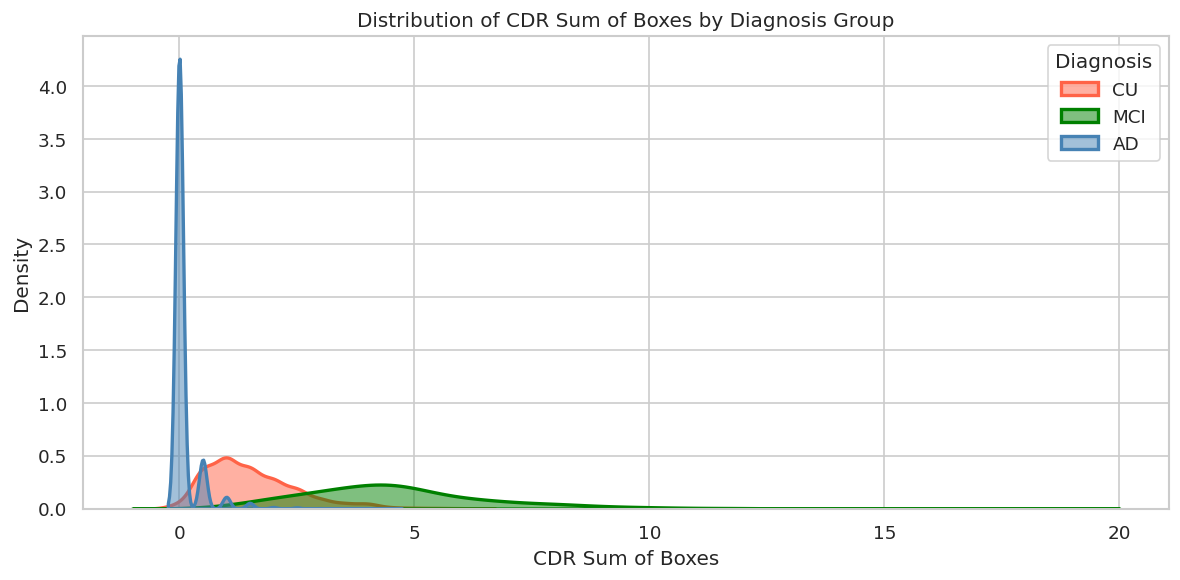

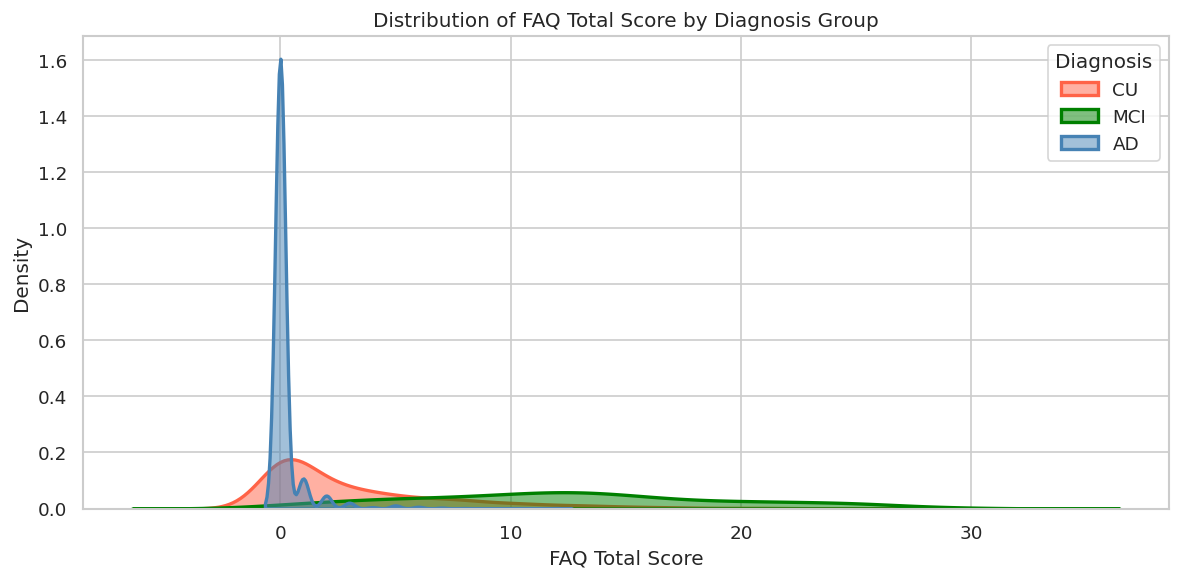

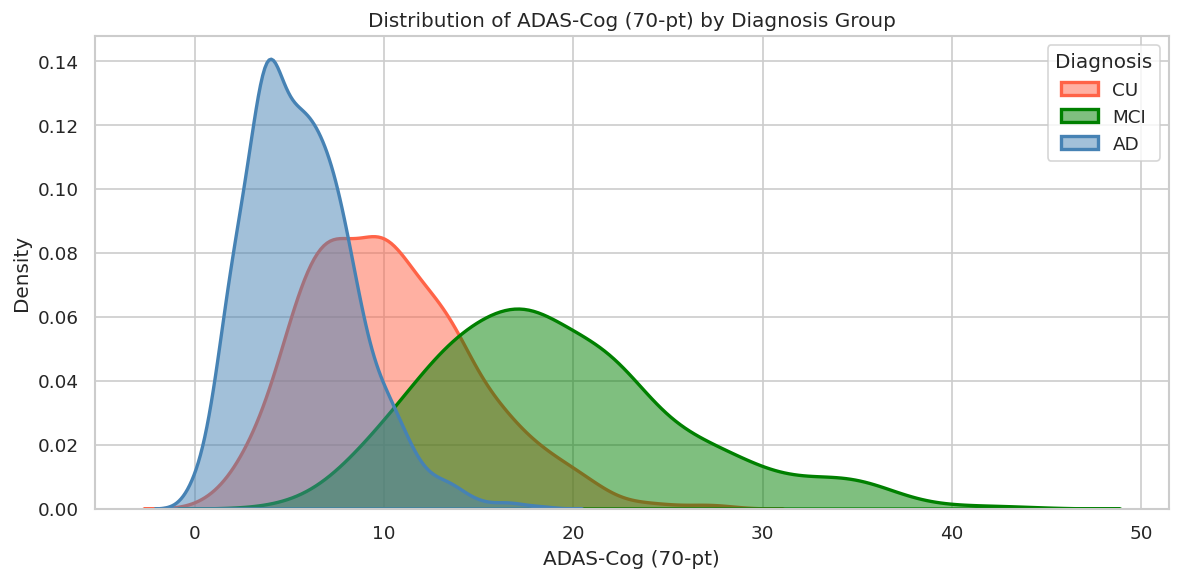

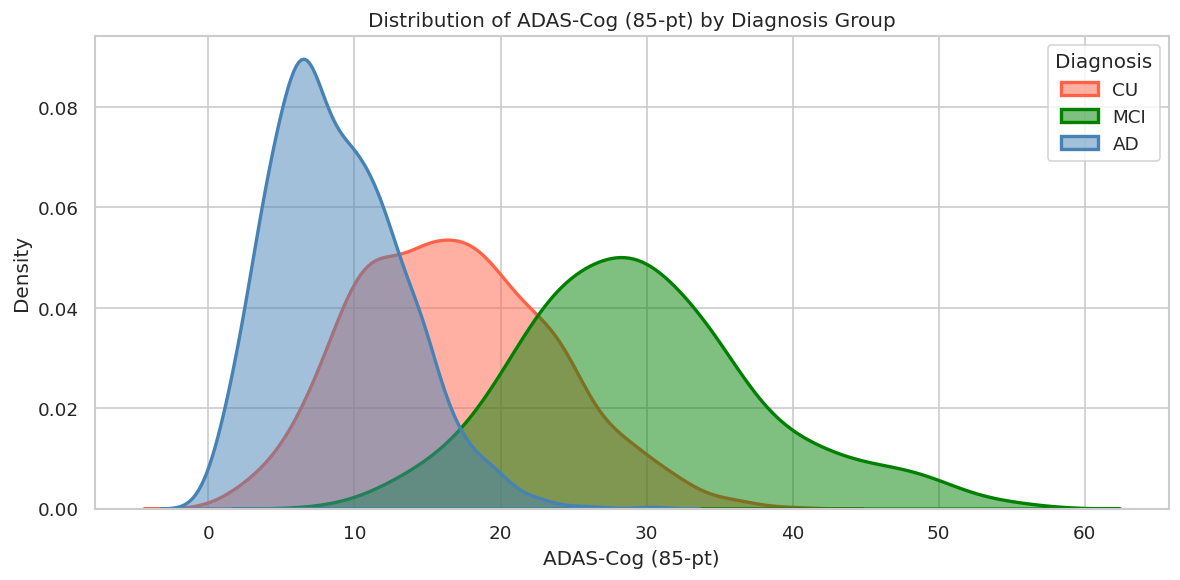

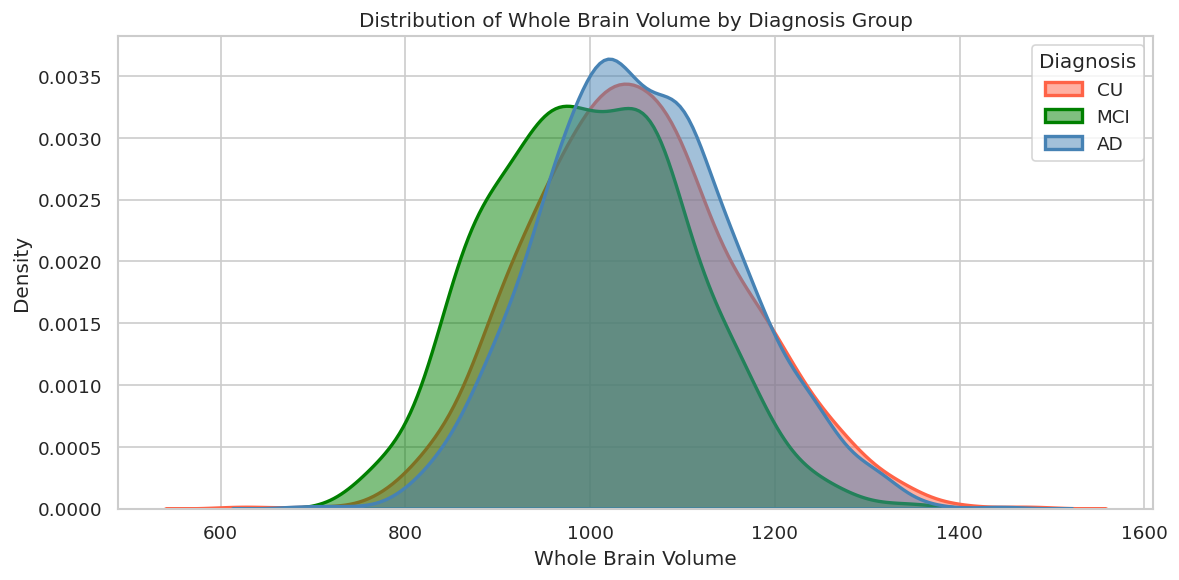

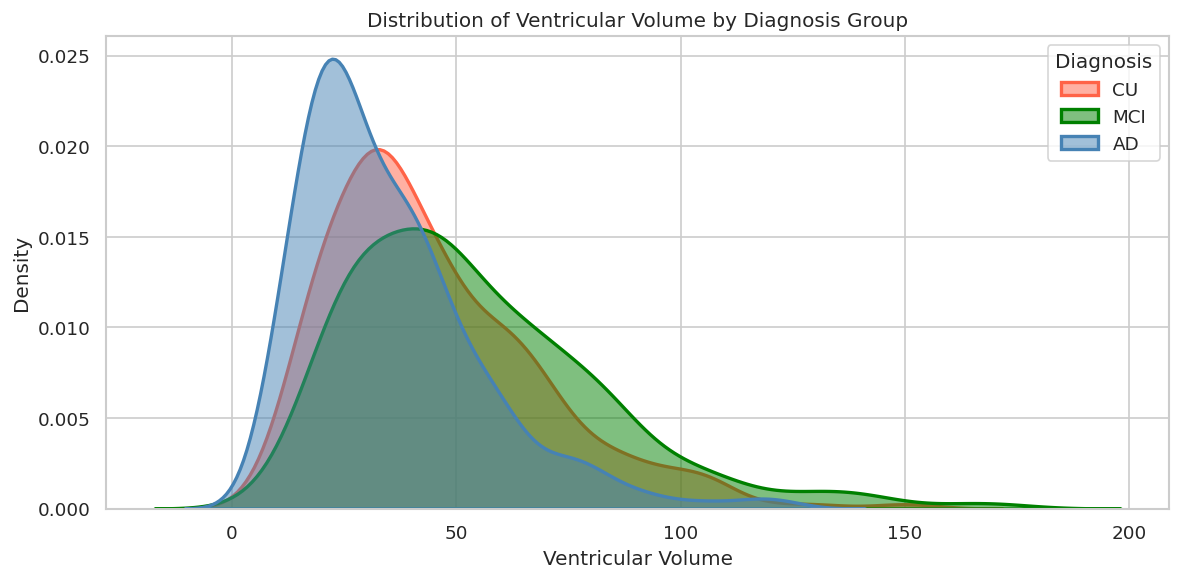

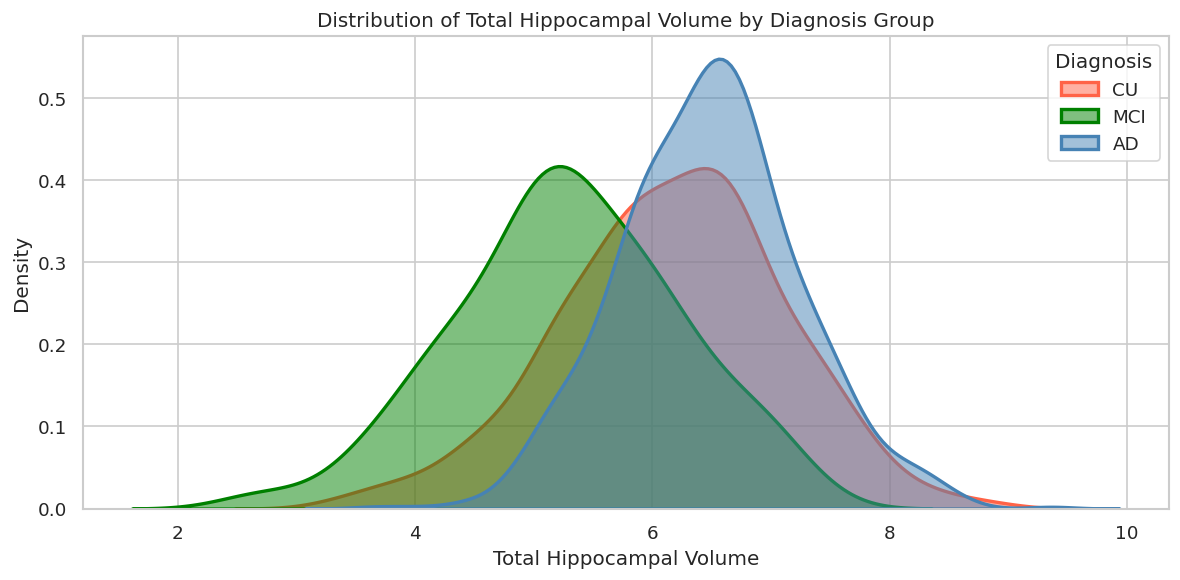

In [16]:
# Map diagnosis labels for better readability
#CHANGE FOR AD
#df_base['DIAGNOSIS_LABEL'] = df_base['DIAGNOSIS'].map({1: 'CU', 2: 'MCI'})
df_base['DIAGNOSIS_LABEL'] = df_base['DIAGNOSIS'].map({1: 'CU', 2: 'MCI', 3: 'AD'})

# 1. Progression counts for CU vs MCI subgroups
print("--- Progression Counts by Diagnosis Subgroup ---")
cu_progression = df_base[df_base['DIAGNOSIS_LABEL'] == 'CU']['PROGRESSOR'].value_counts()
mci_progression = df_base[df_base['DIAGNOSIS_LABEL'] == 'MCI']['PROGRESSOR'].value_counts()

print("\nCU Subgroup Progression:")
print(cu_progression)
print(f"Progression rate in CU: {cu_progression.get(1, 0) / cu_progression.sum() * 100:.1f}%")

print("\nMCI Subgroup Progression:")
print(mci_progression)
print(f"Progression rate in MCI: {mci_progression.get(1, 0) / mci_progression.sum() * 100:.1f}%")

# Visualize progression counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Progression Status within CU and MCI Subgroups', fontsize=16, y=1.02)

# CU Progression
sns.countplot(data=df_base[df_base['DIAGNOSIS_LABEL'] == 'CU'], x='PROGRESSOR', ax=axes[0],
              hue='PROGRESSOR', palette=['steelblue', 'tomato'], legend=False)
axes[0].set_title('CU Subgroup')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Progressor (0)', 'Progressor (1)'])
axes[0].bar_label(axes[0].containers[0])
axes[0].set_ylabel('Count')

# MCI Progression
sns.countplot(data=df_base[df_base['DIAGNOSIS_LABEL'] == 'MCI'], x='PROGRESSOR', ax=axes[1],
              hue='PROGRESSOR', palette=['steelblue', 'tomato'], legend=False)
axes[1].set_title('MCI Subgroup')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Progressor (0)', 'Progressor (1)'])
axes[1].bar_label(axes[1].containers[0])
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# 2. Feature distributions comparison
# Re-using the feature lists and labels from T0dEsDXVGyCF
all_features_to_compare = demographic_features + cognitive_features + imaging_features
categorical_to_compare = ['PTGENDER', 'APOE4_COUNT','PTMARRY']

def plot_distributions_by_diagnosis(df, features, categorical_features_list, feature_labels_map):
    for feature in features:
        plt.figure(figsize=(10, 5))
        title = feature_labels_map.get(feature, feature)

        if feature in categorical_features_list:
            # For categorical features, use countplot
            sns.countplot(data=df, x=feature, hue='DIAGNOSIS_LABEL', palette={'CU': 'steelblue', 'MCI': 'tomato','AD':'green'})
            plt.title(f'Distribution of {title} by Diagnosis Group')
            plt.ylabel('Count')
            if feature == 'PTGENDER':
                plt.xticks([1, 2], ['Male', 'Female'])
            elif feature == 'APOE4_COUNT':
                plt.xlabel('APOE4 Count (0, 1, or 2 copies)')
            plt.legend(title='Diagnosis')
        else:
            # For continuous features, use KDE plot
            sns.kdeplot(data=df, x=feature, hue='DIAGNOSIS_LABEL', fill=True, common_norm=False,
                        palette={'CU': 'steelblue', 'MCI': 'tomato','AD':'green'}, alpha=0.5, linewidth=2)
            plt.title(f'Distribution of {title} by Diagnosis Group')
            plt.xlabel(title)
            plt.ylabel('Density')
            plt.legend(title='Diagnosis', labels=['CU', 'MCI','AD'])

        plt.tight_layout()
        plt.show()

print("\n--- Feature Distributions by Diagnosis Subgroup ---")
plot_distributions_by_diagnosis(df_base, all_features_to_compare, categorical_to_compare, feature_labels)

# Clean up the temporary DIAGNOSIS_LABEL column
df_base.drop(columns=['DIAGNOSIS_LABEL'], inplace=True, errors='ignore')

# **Missing Data analysis**

=== MISSING DATA ANALYSIS (on raw df_base, before imputation) ===


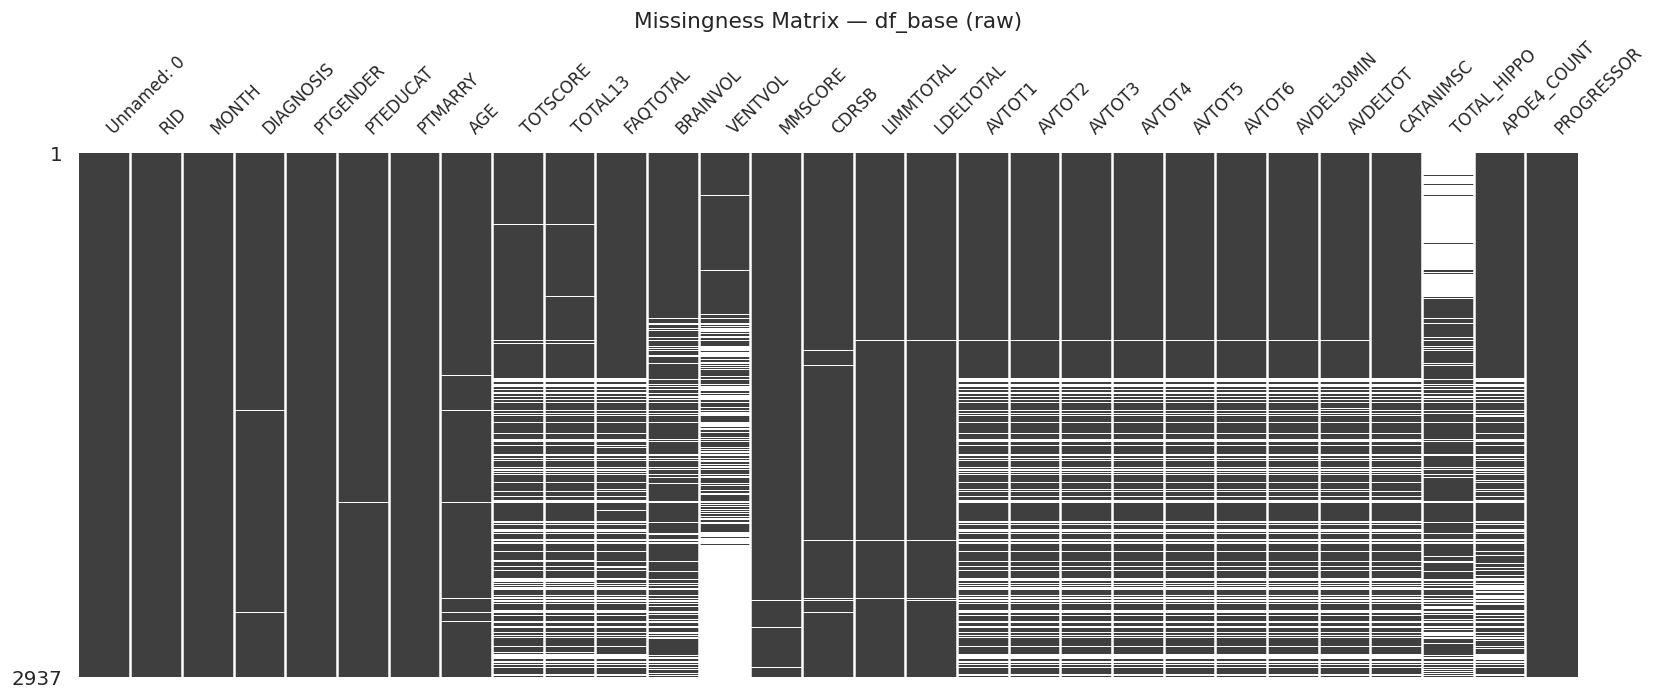

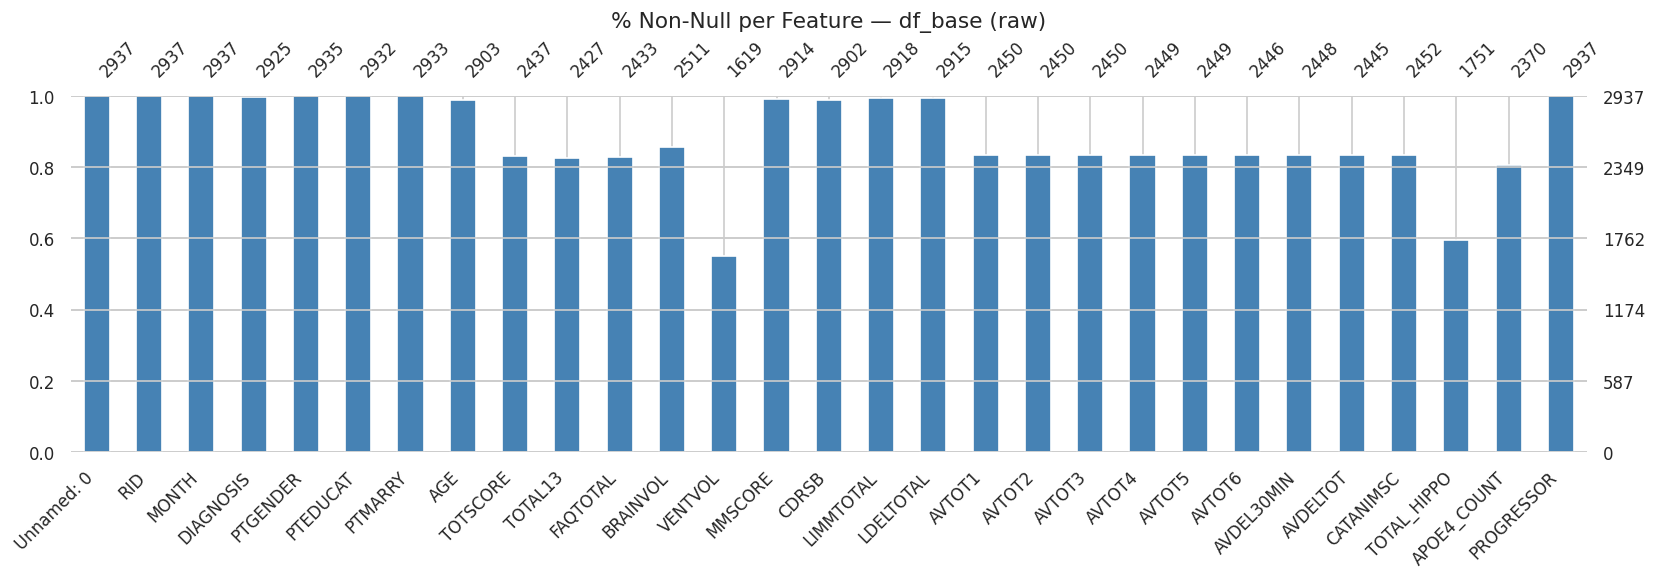

In [17]:
# ── Missing Data Analysis ─────────────────────────────────────────────────────
import missingno as msno

print("=== MISSING DATA ANALYSIS (on raw df_base, before imputation) ===")

# 1a. Matrix: white lines = missing, dark = present.
#     Reveals whether missingness is random or clustered (e.g., patients without PET have ALL imaging missing)
fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(df_base, ax=ax, sparkline=False, fontsize=10)
ax.set_title("Missingness Matrix — df_base (raw)", fontsize=13)
plt.tight_layout()
plt.show()

# 1b. Bar chart: percentage present per feature
fig, ax = plt.subplots(figsize=(14, 5))
msno.bar(df_base, ax=ax, fontsize=10, color='steelblue')
ax.set_title("% Non-Null per Feature — df_base (raw)", fontsize=13)
plt.tight_layout()
plt.show()

# **Imputation**

In [18]:
features_to_impute = [
    'TOTSCORE', 'TOTAL13', 'FAQTOTAL', 'BRAINVOL', 'VENTVOL',
    'AVTOT1', 'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5', 'AVTOT6',
    'AVDEL30MIN', 'AVDELTOT', 'CATANIMSC', 'TOTAL_HIPPO', 'APOE4_COUNT',
    'DIAGNOSIS', 'PTGENDER', 'PTEDUCAT', 'PTMARRY', 'AGE',
    'MMSCORE', 'CDRSB', 'LIMMTOTAL', 'LDELTOTAL'
]

from sklearn.linear_model import BayesianRidge

imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,       # BayesianRidge converges faster
    random_state=42,
    initial_strategy='median',
    imputation_order='ascending'  # impute least-missing features first
)

df_features = df_base[features_to_impute].copy()
imputed_data = imputer.fit_transform(df_features)
df_imputed = pd.DataFrame(imputed_data, columns=features_to_impute)

# Post-processing
df_imputed['APOE4_COUNT'] = df_imputed['APOE4_COUNT'].round().astype(int).clip(0, 2)
df_imputed['PTGENDER'] = df_imputed['PTGENDER'].round().clip(1, 2)
df_imputed['PTMARRY'] = df_imputed['PTMARRY'].round().astype(int)
df_imputed['DIAGNOSIS'] = df_imputed['DIAGNOSIS'].round().astype(int).clip(1, 3)

# Re-attach non-imputed columns
df_imputed['RID'] = df_base['RID'].values
df_imputed['MONTH'] = df_base['MONTH'].values
df_imputed['PROGRESSOR'] = df_base['PROGRESSOR'].values

print("Missing values AFTER imputation:")
print(df_imputed.isnull().sum())

Missing values AFTER imputation:
TOTSCORE       0
TOTAL13        0
FAQTOTAL       0
BRAINVOL       0
VENTVOL        0
AVTOT1         0
AVTOT2         0
AVTOT3         0
AVTOT4         0
AVTOT5         0
AVTOT6         0
AVDEL30MIN     0
AVDELTOT       0
CATANIMSC      0
TOTAL_HIPPO    0
APOE4_COUNT    0
DIAGNOSIS      0
PTGENDER       0
PTEDUCAT       0
PTMARRY        0
AGE            0
MMSCORE        0
CDRSB          0
LIMMTOTAL      0
LDELTOTAL      0
RID            0
MONTH          0
PROGRESSOR     0
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [19]:
df_imputed.columns

Index(['TOTSCORE', 'TOTAL13', 'FAQTOTAL', 'BRAINVOL', 'VENTVOL', 'AVTOT1',
       'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5', 'AVTOT6', 'AVDEL30MIN',
       'AVDELTOT', 'CATANIMSC', 'TOTAL_HIPPO', 'APOE4_COUNT', 'DIAGNOSIS',
       'PTGENDER', 'PTEDUCAT', 'PTMARRY', 'AGE', 'MMSCORE', 'CDRSB',
       'LIMMTOTAL', 'LDELTOTAL', 'RID', 'MONTH', 'PROGRESSOR'],
      dtype='object')

In [ ]:
features_to_plot = [f for f in features_to_impute]

n_cols = 3
n_rows = (len(features_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]

    # Original non‑null values
    orig = df_base[feature].dropna()

    # Imputed full series
    imputed = df_imputed[feature]

        # KDE overlay for continuous
    sns.kdeplot(orig, ax=ax, color='steelblue', label='Original (non-null)', linewidth=2)
    sns.kdeplot(imputed, ax=ax, color='darkorange', label='Imputed', linewidth=2)
    ax.set_title(f'{feature}', fontsize=11)
    ax.legend(fontsize=8)

    ax.set_ylabel('Density', fontsize=9)
    ax.tick_params(labelsize=8)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('MICE Imputation Validation: Before vs. After Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# **Outlier detection & capping**

In [ ]:
avtot_cols = ['AVTOT1', 'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5', 'AVTOT6']
trials = np.array([1, 2, 3, 4, 5, 6])

def compute_avr(row):
    values = row[avtot_cols].values.astype(float)
    if np.isnan(values).any():
        return np.nan
    return np.average(values)


df_imputed['RAVLT_AVERAGE'] = df_imputed[avtot_cols].apply(compute_avr, axis=1).values
df_imputed.drop(columns=avtot_cols, inplace=True)

In [ ]:
df_imputed.PROGRESSOR.value_counts()

In [ ]:
# ── Outlier Detection & Capping ───────────────────────────────────────────────
# Strategy: IQR capping (Winsorization) for continuous cognitive/demographic features
# Clinical hard bounds for CENTILOIDS (PET-validated range)
# Never cap: binary, ordinal, or categorical features

df_clean = df_imputed.copy()

# ── Define feature groups ─────────────────────────────────────────────────────
iqr_features = [
    'PTEDUCAT',
    'LIMMTOTAL',
    'LDELTOTAL',
    'RAVLT_AVERAGE',
    'AVDEL30MIN',
    'AVDELTOT',
    'CATANIMSC',
    'MMSCORE',
    'CDRSB',
    'FAQTOTAL',
    'TOTSCORE',
    'TOTAL13',
    'BRAINVOL',
    'VENTVOL',
    'TOTAL_HIPPO',
]

# ── Step 1: Detect outliers BEFORE capping ────────────────────────────────────
print("=== OUTLIER DETECTION (before capping) ===\n")
outlier_report = []

for col in iqr_features:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_low  = (df_clean[col] < lower).sum()
    n_high = (df_clean[col] > upper).sum()
    n_total = n_low + n_high
    pct    = n_total / len(df_clean) * 100

    outlier_report.append({
        'Feature': col, 'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'Outliers Below': n_low, 'Outliers Above': n_high,
        'Total Outliers': n_total, '% Affected': round(pct, 1)
    })

report_df = pd.DataFrame(outlier_report).sort_values('Total Outliers', ascending=False)
print(report_df.to_string(index=False))

In [ ]:
n = len(iqr_features)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
fig.suptitle('Outlier Detection — Before Capping', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(iqr_features):
    sns.boxplot(data=df_clean, y=col, ax=axes[i], color='steelblue', width=0.4,
                flierprops=dict(marker='o', markerfacecolor='tomato', markersize=4))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ── Step 3: Apply IQR capping ─────────────────────────────────────────────────
bounds = {}  # store bounds for documentation

for col in iqr_features:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    bounds[col] = (lower, upper)
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

# CENTILOIDS: clinical hard bounds (validated PET range, not IQR)
# -39 = SUVR floor, 201 = biological ceiling for amyloid burden
if 'CENTILOIDS' in df_clean.columns:
    df_clean['CENTILOIDS'] = df_clean['CENTILOIDS'].clip(lower=-39, upper=201)
    print("✅ CENTILOIDS capped at clinical bounds [-39, 201]")

print("✅ IQR capping applied to all continuous features")
print(f"   Shape unchanged: {df_clean.shape}")

In [ ]:
# ── Step 4: Before vs After comparison (KDE overlay) ─────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
fig.suptitle('Before vs After Capping — Distribution Comparison', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(iqr_features):
    ax = axes[i]
    df_imputed[col].plot(kind='kde', ax=ax, color='steelblue',
                         linewidth=1.5, label='Before', linestyle='--')
    df_clean[col].plot(kind='kde', ax=ax, color='tomato',
                       linewidth=1.5, label='After')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ Distributions preserved — capping only compressed extreme tails")

# **Correlation**

In [ ]:
# ── 8a. Full Correlation Heatmap ──────────────────────────────────────────────

corr_features = [
    # Demographics
    'AGE_AT_VISIT', 'PTEDUCAT', 'APOE4_COUNT',
    # Cognitive
    'LIMMTOTAL', 'LDELTOTAL',
    'AVTOT4', 'AVDEL30MIN', 'AVDELTOT',
    'TRAASCOR', 'TRABSCOR',
    'CATANIMSC', 'CATVEGESC',
    # Imaging
    'CENTILOIDS',
    # Engineered
    'RAVLT_SLOPE', 'TRAIL_RATIO', 'APOE4_CENTILOIDS',
    # Target
    'DIAGNOSIS', 'PROGRESSOR'
]

# Only keep columns that exist in df_clean
corr_features = [c for c in corr_features if c in df_clean.columns]

# Use pairwise complete obs — no fillna, no distortion
corr_matrix = df_clean[corr_features].corr(method='pearson')

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.4,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (Pairwise Complete Observations)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pointbiserialr

features_corr =[
    # Demographics
    'PTGENDER',
    'PTEDUCAT',
    'PTMARRY',
    'APOE4_COUNT',
    'AGE',
    # Cognitive
    'LIMMTOTAL'
    'LDELTOTAL',
    'AVTOT1', 'AVTOT2', 'AVTOT3', 'AVTOT4', 'AVTOT5', 'AVTOT6',
    'AVDEL30MIN',
    'AVDELTOT',
    'CATANIMSC',
    'MMSCORE',
    'CDRSB',
    'FAQTOTAL',
    'TOTSCORE',
    'TOTAL13',
    # Imaging
    'BRAINVOL',
    'VENTVOL',
    'TOTAL_HIPPO'
]
features_corr = [c for c in features_corr if c in df_clean.columns]

print('=== Point-Biserial Correlation with PROGRESSOR ===\n')
results = []
for col in features_corr:
    # Drop NaN pairs for this specific feature only
    pair = df_clean[[col, 'PROGRESSOR']].dropna()
    n = len(pair)

    # Handle PTGENDER for point-biserial correlation (temporarily convert to numeric)
    if col == 'PTGENDER':
        temp_gender = pair[col].map({'Female': 0, 'Male': 1})
        corr, pval = pointbiserialr(temp_gender, pair['PROGRESSOR'])
    else:
        corr, pval = pointbiserialr(pair[col], pair['PROGRESSOR'])

    results.append({
        'Feature':     col,
        'Correlation': round(corr, 3),
        'P-value':     round(pval, 4),
        'N (pairs)':   n,
        'Significant': '✓' if pval < 0.05 else '✗' # Replaced glyphs
    })

corr_df = pd.DataFrame(results).sort_values('Correlation', key=abs, ascending=False)
print(corr_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in corr_df['Correlation']]
bars = ax.barh(corr_df['Feature'], corr_df['Correlation'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)

# Mark significant features
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row['Significant'] == '✓': # Replaced glyphs
        ax.text(row['Correlation'] + 0.002 if row['Correlation'] > 0 else row['Correlation'] - 0.002,
                i, '✓', va='center', fontsize=7)

ax.set_title('Point-Biserial Correlation with PROGRESSOR', fontsize=13)
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [ ]:
df_clean.to_csv(processed_path + 'df_clean_AD.csv', index=False)